**Importações**

In [109]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

import torch 
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR

import warnings
warnings.filterwarnings('ignore')


In [110]:
df = pd.read_csv('C:\\Users\\souza\\Downloads\\Projeto 2 -revisão de produtividade de funcionários\\garments_worker_productivity.csv')
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


**Estatistica descritiva**

In [111]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [112]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [113]:
#substituiçao de dados nulos pela mediana 
df['wip'] = df['wip'].interpolate(method='linear', limit_direction='forward')

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [115]:
df['department'].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [116]:
df['quarter'].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

In [117]:
df['date'] = pd.to_datetime(df['date'])

**EDA**


**Análise Univariada**

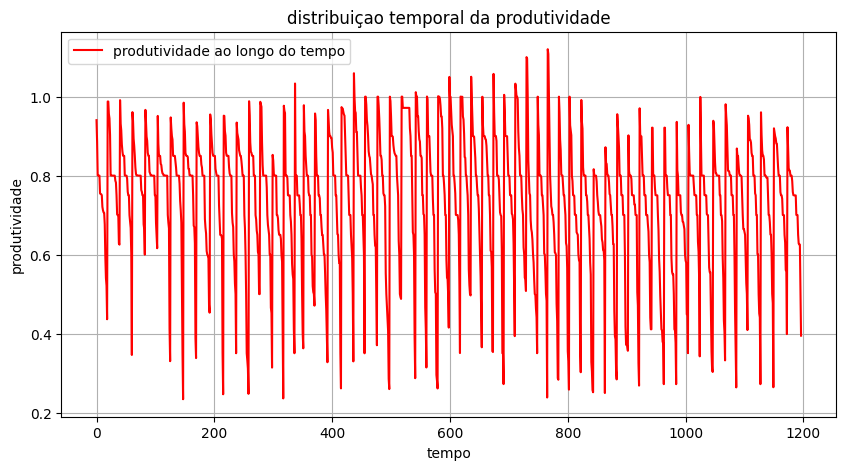

In [118]:
#distribuiçao temporal da produtividade
plt.figure(figsize=(10,5))
plt.title('distribuiçao temporal da produtividade')
sns.lineplot(df['actual_productivity'], color='red', label='produtividade ao longo do tempo')
plt.xlabel('tempo')
plt.ylabel('produtividade')
plt.grid()
plt.show()


In [119]:
#separaçao dados numericos e dados categoricos 
num_col = df.select_dtypes(exclude=['object', 'datetime64[ns]'])
cat_col = df.select_dtypes(exclude=['number', 'datetime64[ns]']).columns

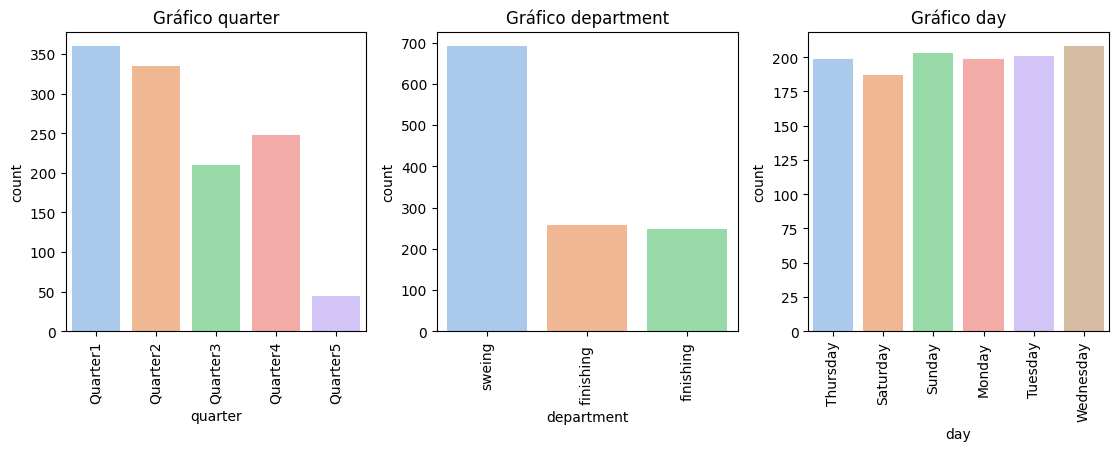

In [120]:
#distribuiçao dados categoricos
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, cat in enumerate(cat_col):
    sns.countplot(data=df, x=cat, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Gráfico {cat}')
    axes[i].tick_params(axis='x', rotation=90)
for j in range(len(cat_col), 12):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

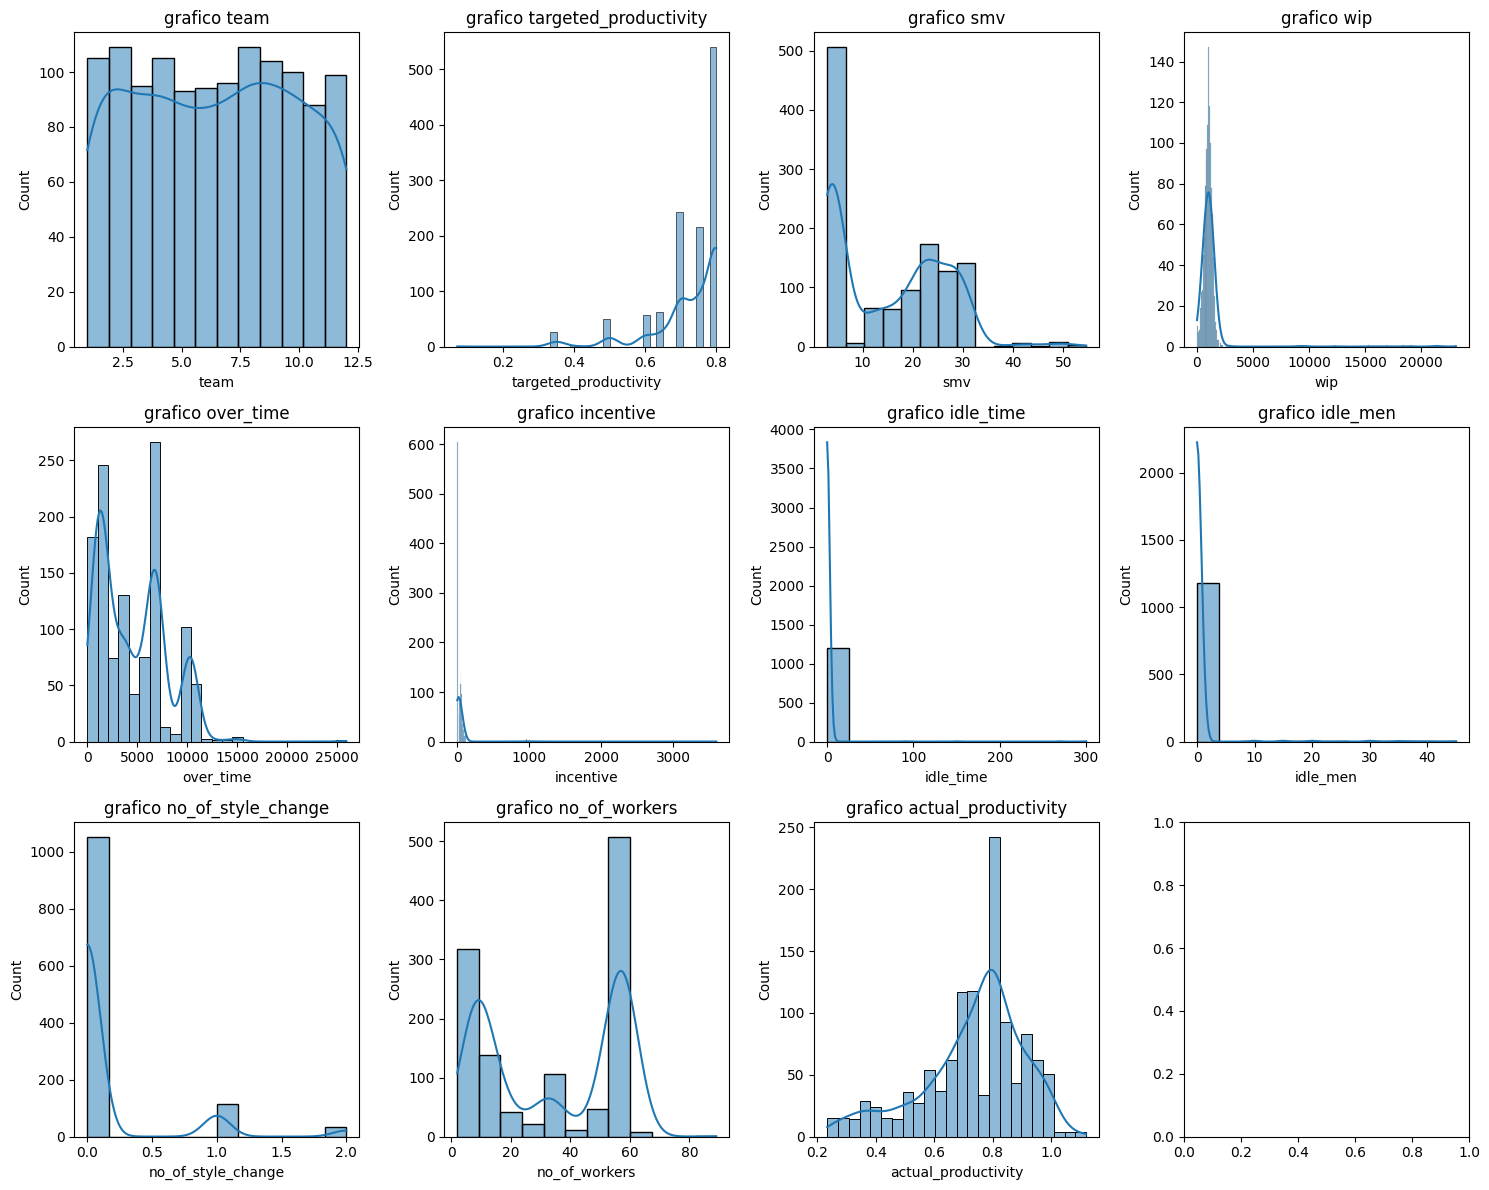

In [121]:
#distribuiçao dados numericos
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, num in enumerate(num_col):
    sns.histplot(df[num], kde=True, ax=axes[i], palette='pastel')
    axes[i].set_title(f'grafico {num}')
for j in range(len(num_col), 9):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


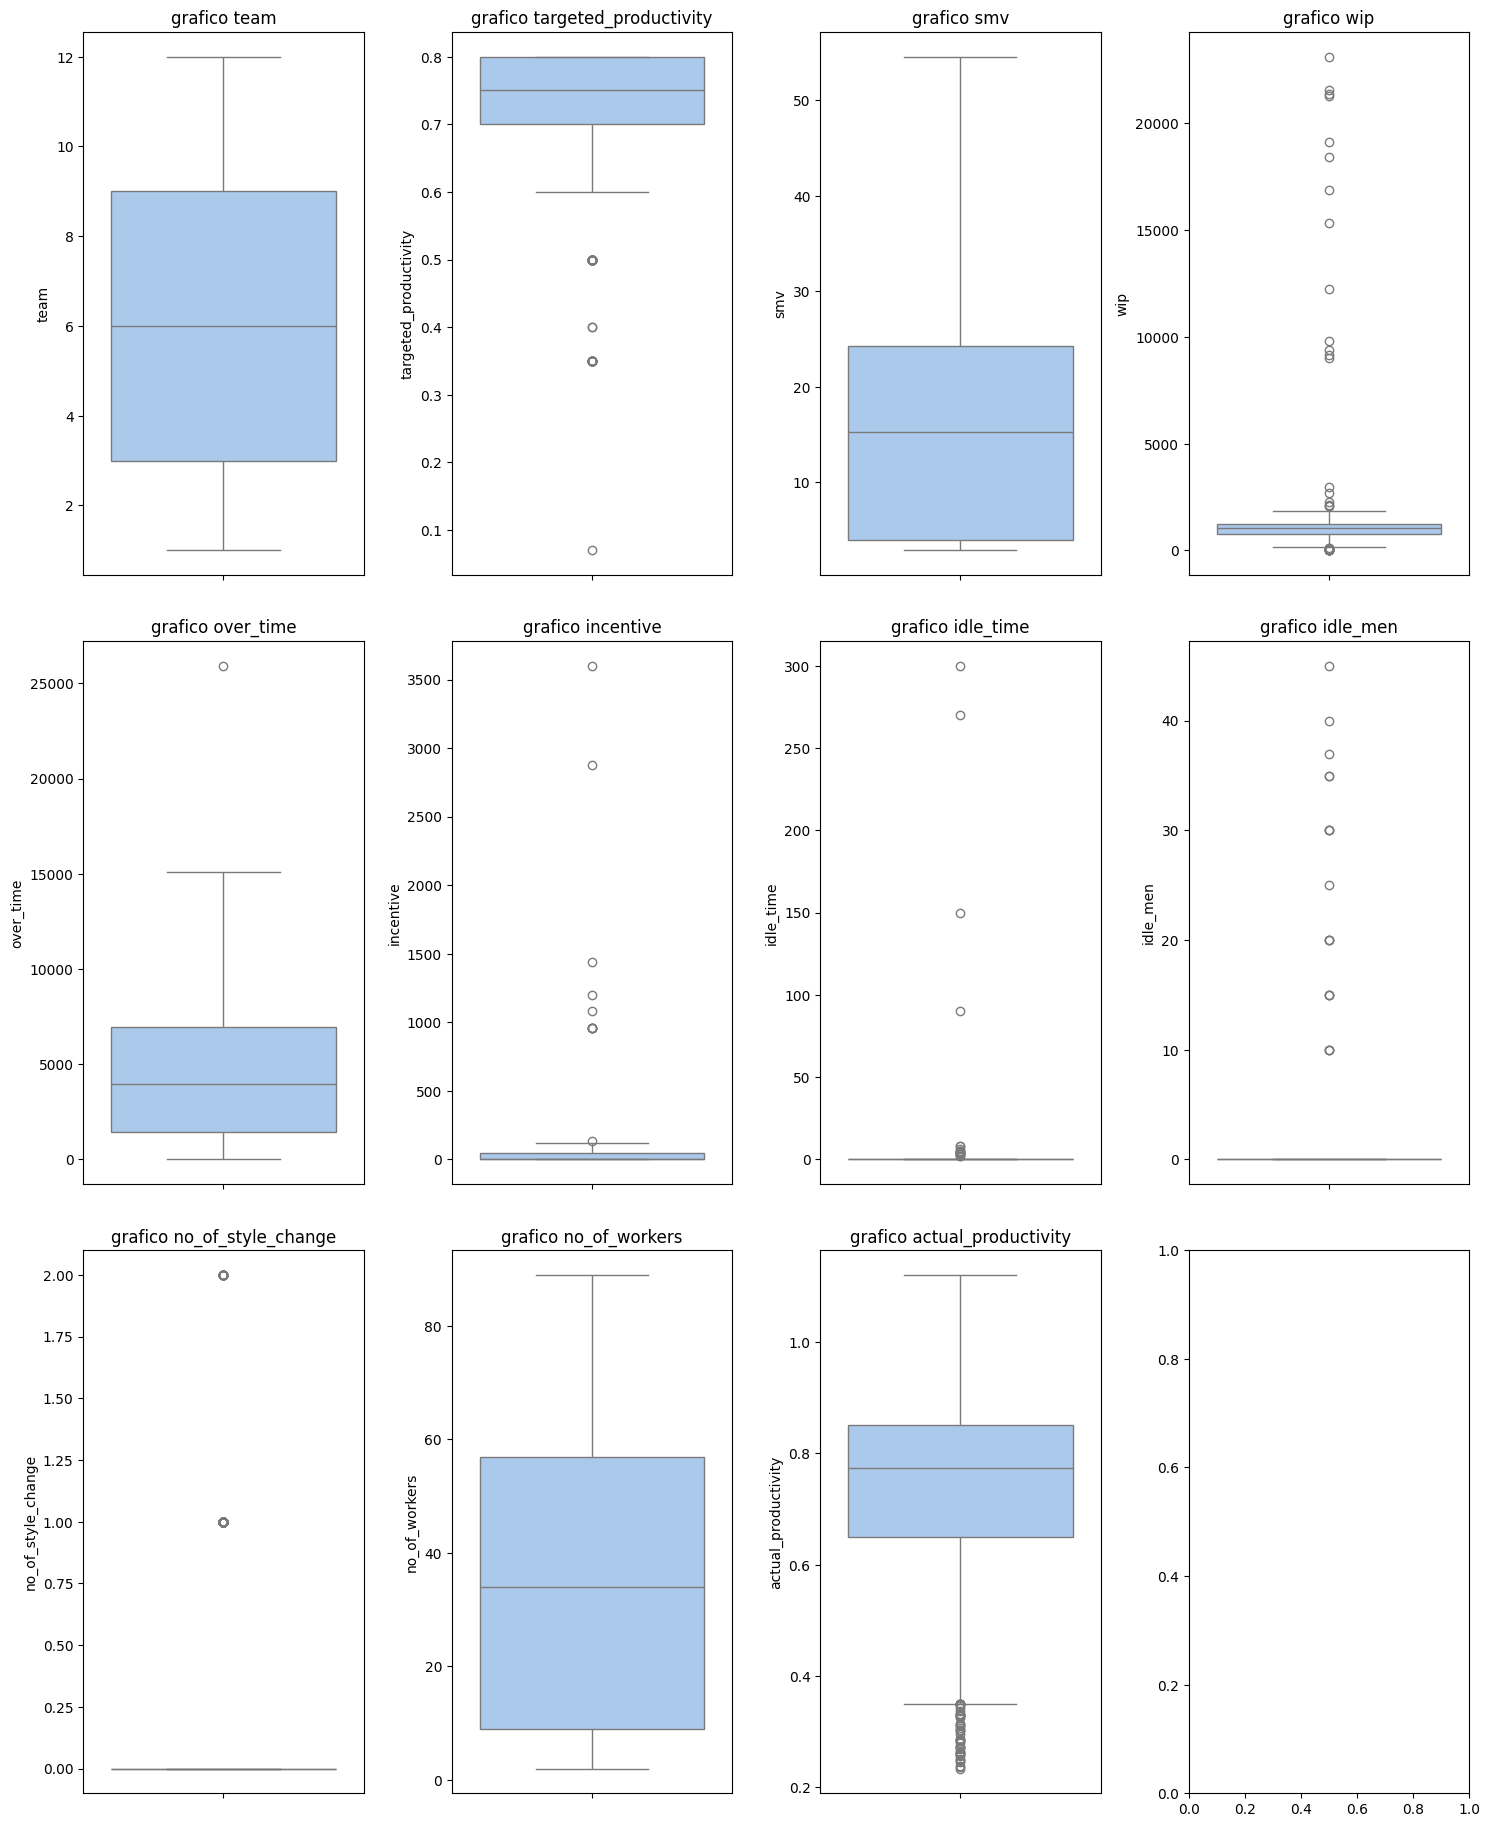

In [122]:
#vizualizaçao em caixa colunas numericas 
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, num in enumerate(num_col):
    sns.boxplot(df[num], ax=axes[i], palette='pastel')
    axes[i].set_title(f'grafico {num}')
for j in range(len(num_col), 9):
    axes[j].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(top=1.5)
plt.show()


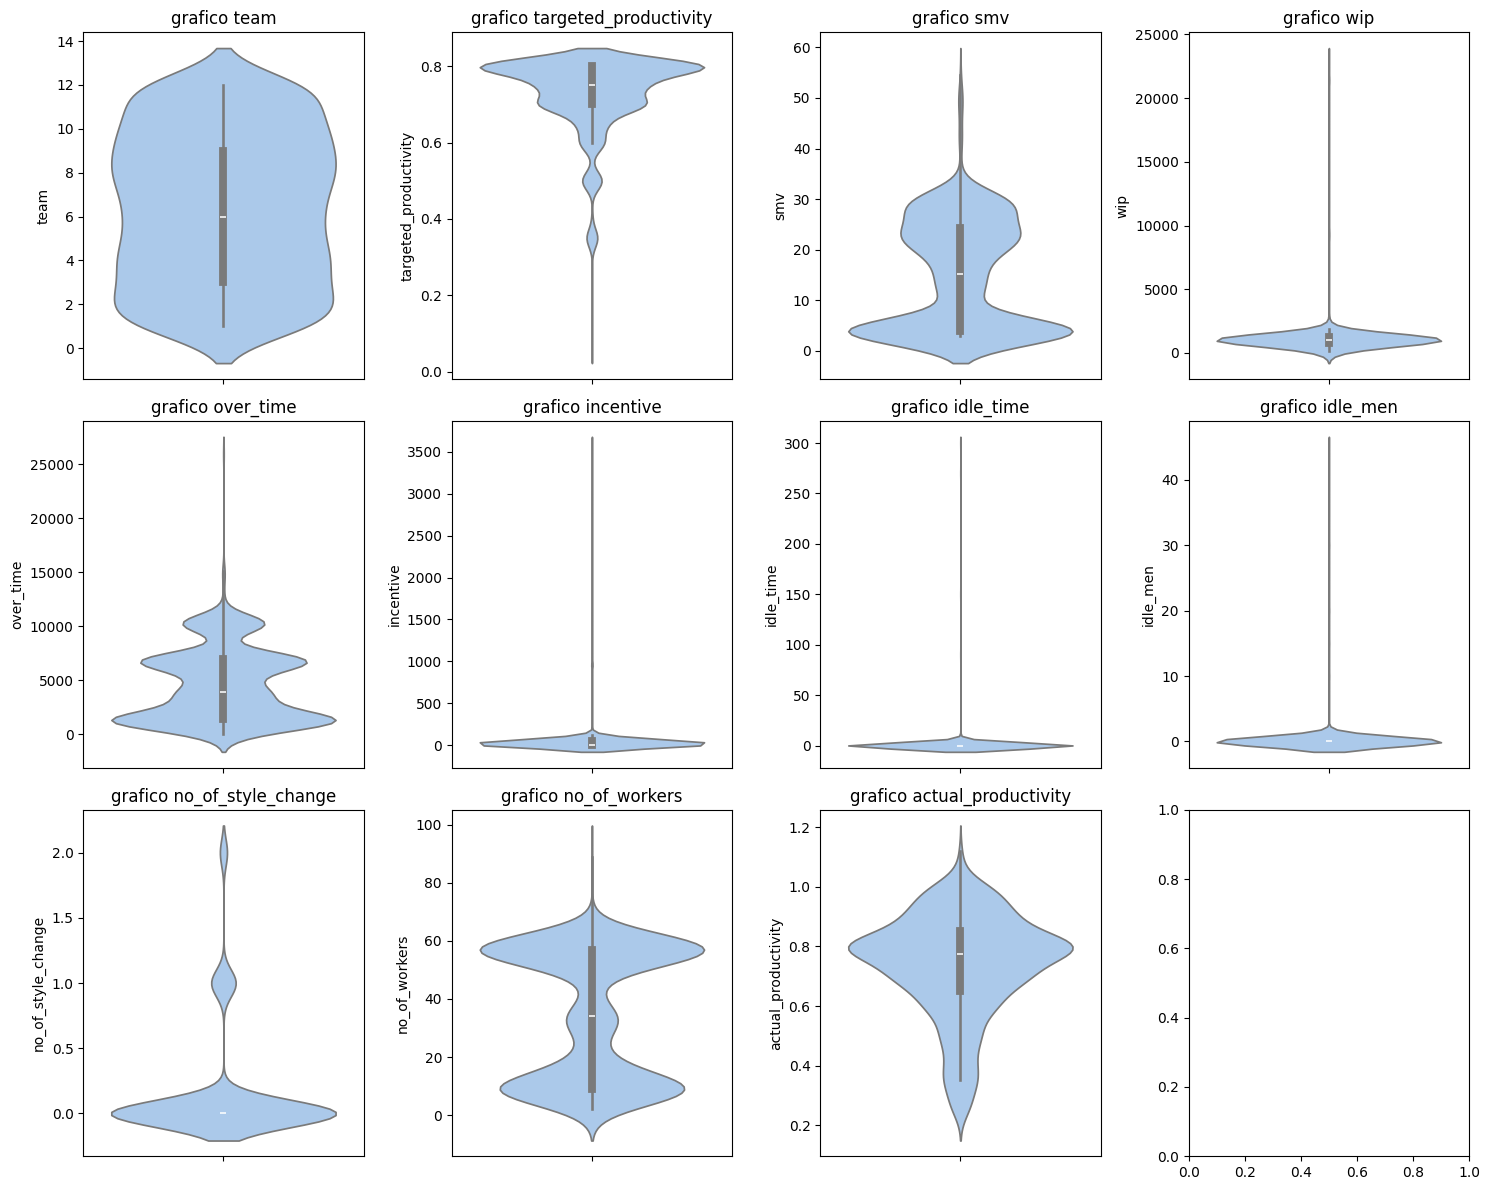

In [123]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, num in enumerate(num_col):
    sns.violinplot(df[num], ax=axes[i], palette='pastel')
    axes[i].set_title(f'grafico {num}')
for j in range(len(num_col), 9):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


**Análise Bivariada**

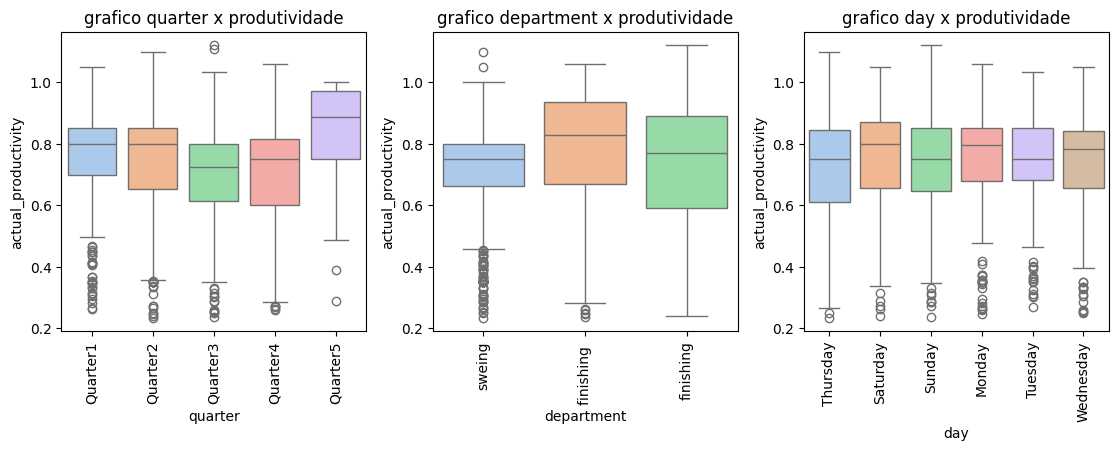

In [124]:
#plot colunas cat x produtividade 
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, cat in enumerate(cat_col):
    sns.boxplot(x=df[cat], y = df['actual_productivity'], ax=axes[i], palette='pastel')
    axes[i].set_title(f'grafico {cat} x produtividade')
    axes[i].tick_params(axis='x', rotation=90)
for j in range(len(cat_col), 12):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [125]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

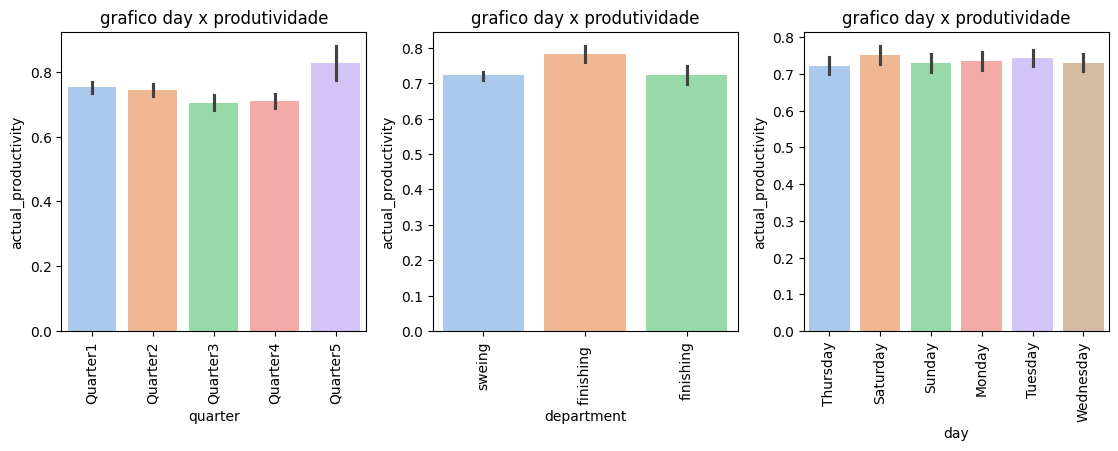

In [ ]:
#grafico de barras cat_col x produtividade
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, bar in enumerate(cat_col):
    sns.barplot(x=df[bar], y = df['actual_productivity'], ax=axes[i], palette='pastel')
    axes[i].set_title(f'grafico {bar} x produtividade')
    axes[i].tick_params(axis='x', rotation=90)
for j in range(len(cat_col), 12):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [127]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

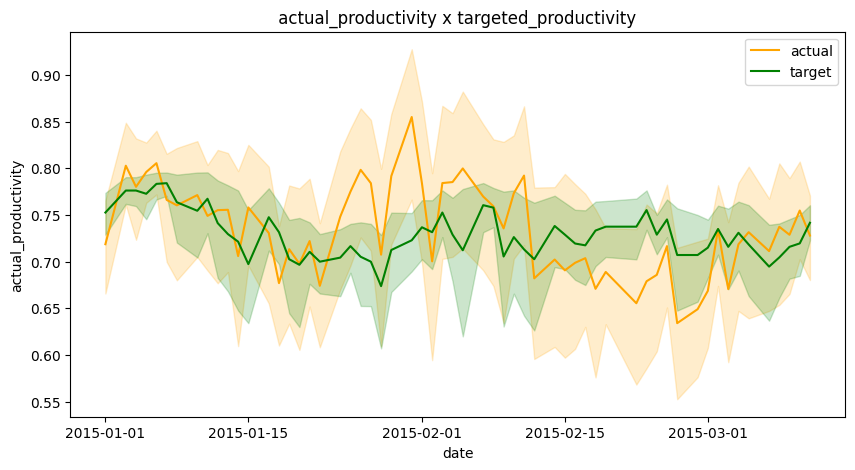

In [128]:
#analise temporal actual_productivity x targeted_productivity 
plt.figure(figsize=(10,5))
plt.title(' actual_productivity x targeted_productivity ')
sns.lineplot(data=df,x='date', y='actual_productivity', color='orange',label='actual')
sns.lineplot(data=df,x='date', y='targeted_productivity', color='green', label='target')
plt.legend()
plt.show()

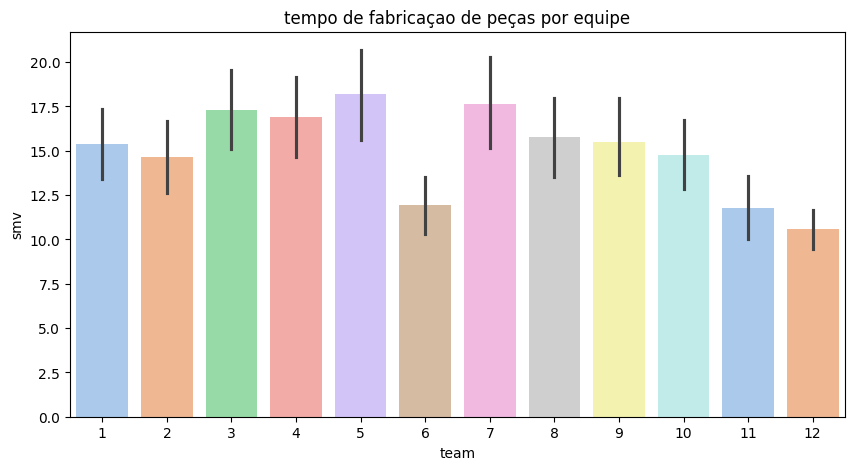

In [129]:
#tempo de fabricaçao de peças por equipes 
plt.figure(figsize=(10,5))
plt.title('tempo de fabricaçao de peças por equipe')
sns.barplot(data=df, x='team', y='smv', palette='pastel')
plt.show()


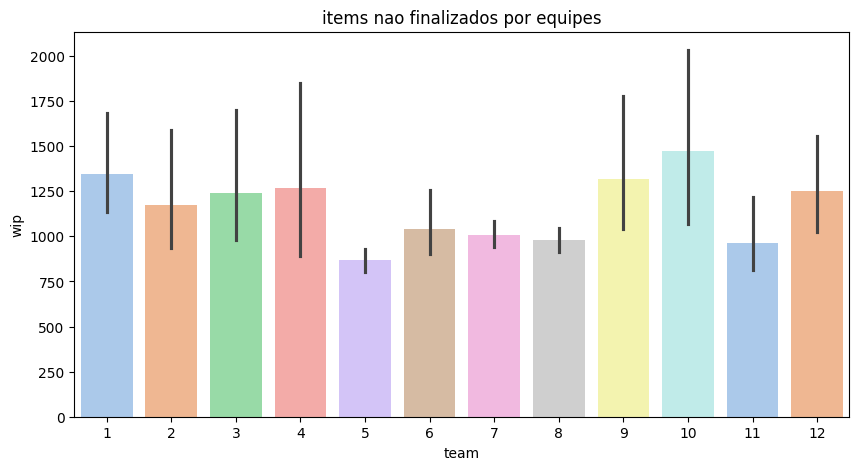

In [130]:
#items nao finalizados por equipes
plt.figure(figsize=(10,5))
plt.title('items nao finalizados por equipes')
sns.barplot(x=df['team'], y= df['wip'], palette='pastel')
plt.show()


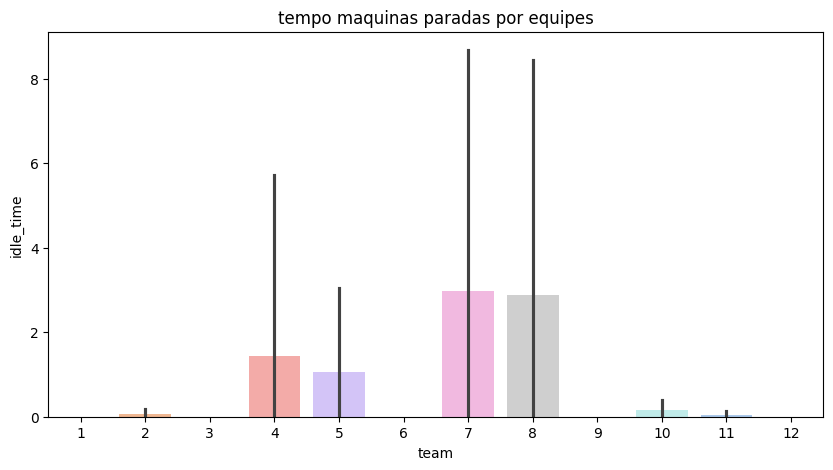

In [131]:
#tempo maquina parada por equipe 
plt.figure(figsize=(10,5))
plt.title('tempo maquinas paradas por equipes')
sns.barplot(x=df['team'], y=df['idle_time'], palette='pastel') 
plt.show()


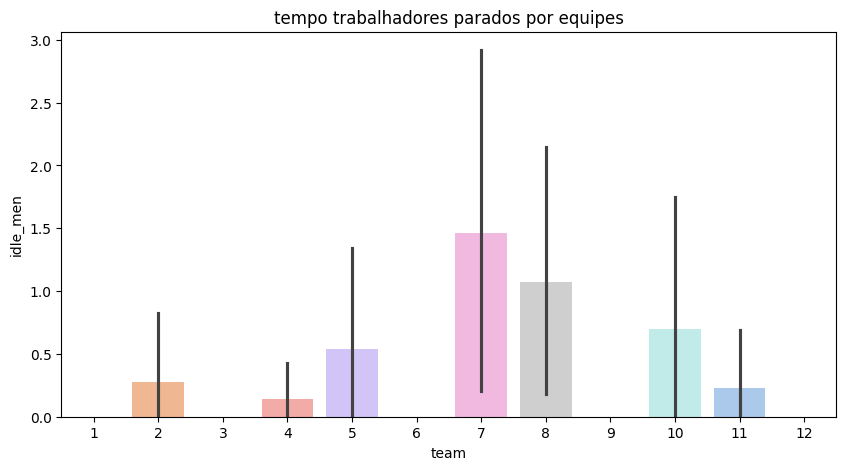

In [132]:
#tempo trabalhadores parados por equipes 
plt.figure(figsize=(10,5))
plt.title('tempo trabalhadores parados por equipes')
sns.barplot(x=df['team'], y=df['idle_men'], palette='pastel')
plt.show()

**Analise Multivariada**

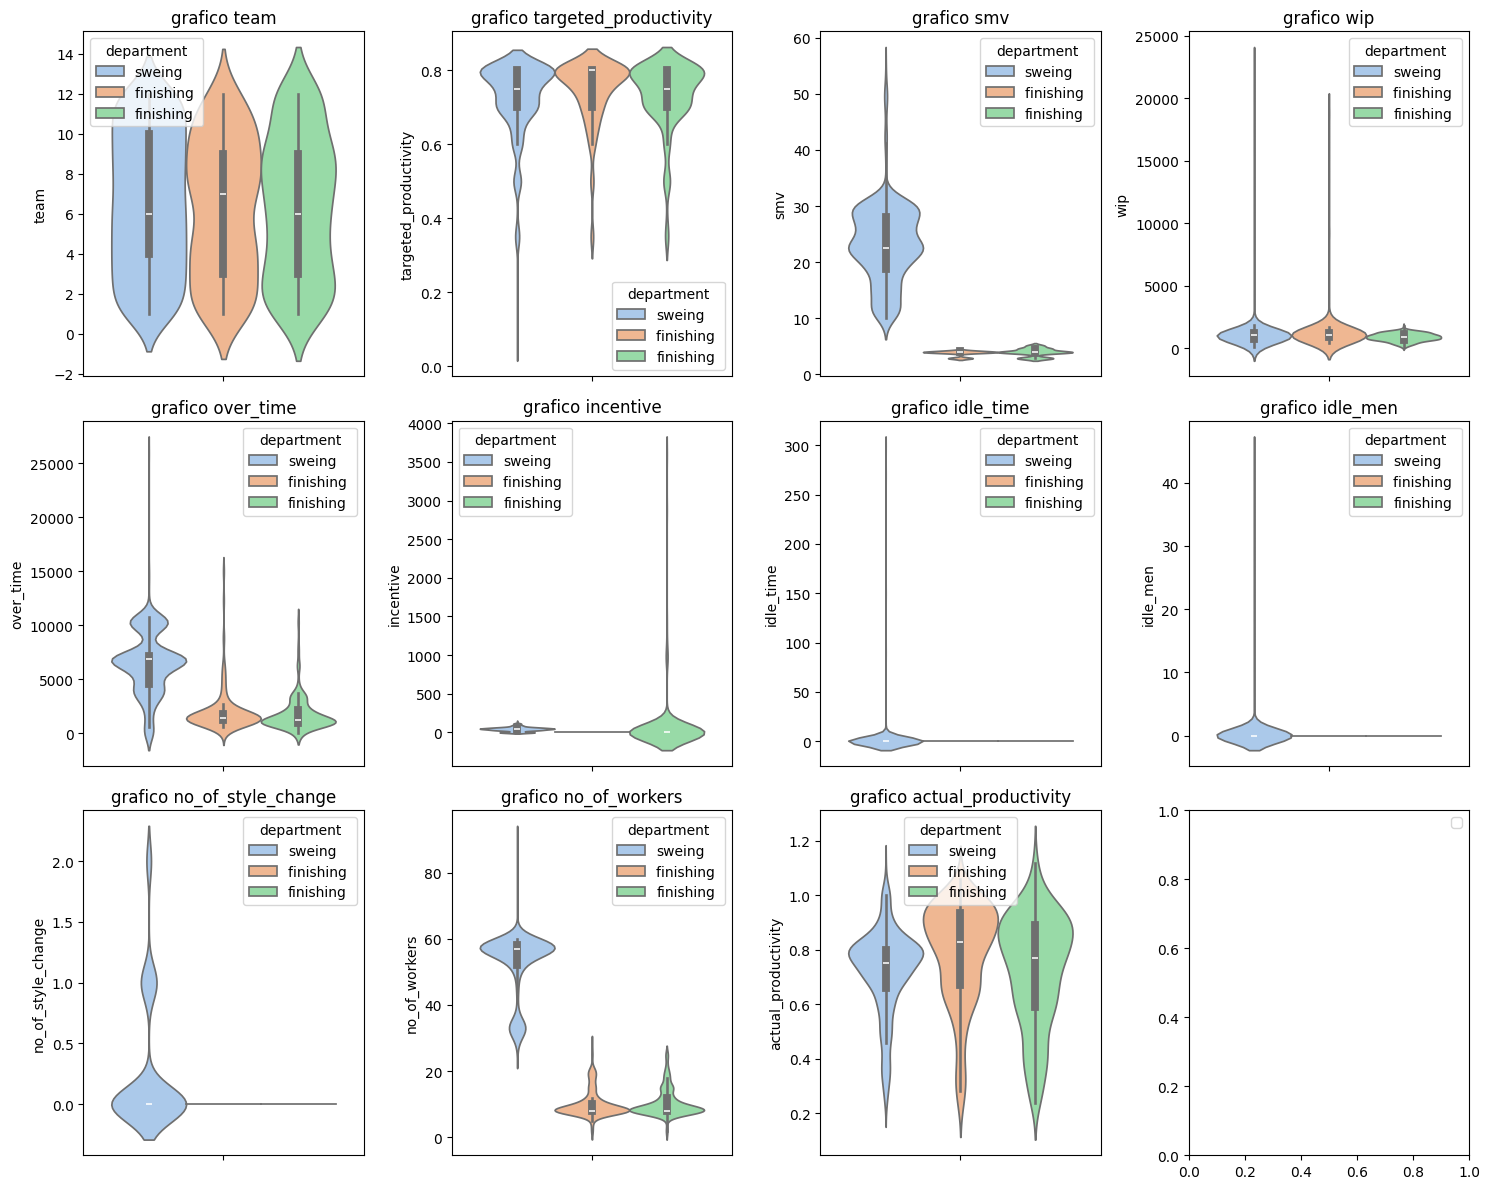

In [133]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()
for i, num in enumerate(num_col):
    sns.violinplot(y=df[num], ax=axes[i], palette='pastel', hue=df['department'])
    axes[i].set_title(f'grafico {num}')
for j in range(len(num_col), 9):
    axes[j].set_visible(False)
plt.tight_layout()
plt.legend()
plt.show()


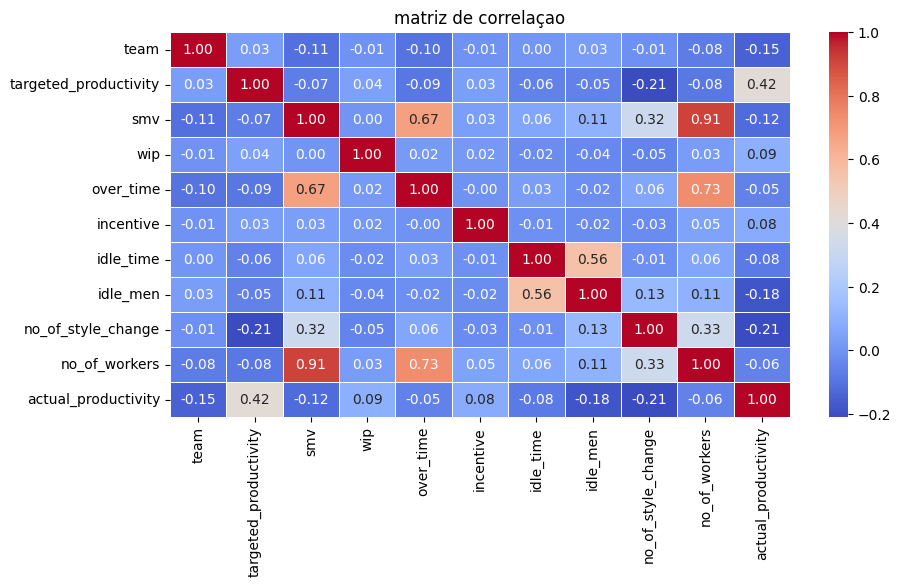

In [134]:
#matriz de correlaçao entre variaveis 
plt.figure(figsize=(10,5))
plt.title('matriz de correlaçao')
sns.heatmap(num_col.corr(),annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.show()

**Respondendo algumas perguntas pós EDA**

Em nosso dataset, há 3 departamentos: 1 Sweing (costura) e 2 finishing(finalizaçao)

como foi a meta de produtividade por produtividade alcançada pelas equipes?

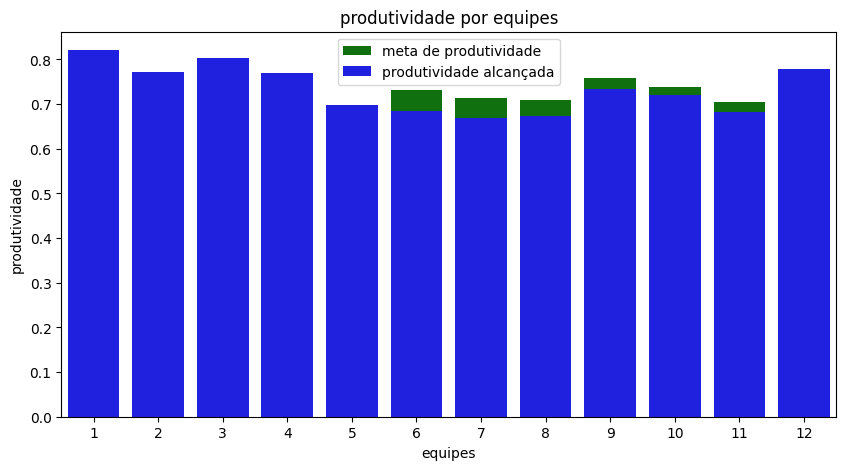

In [135]:
#produtividades por equipes 
plt.figure(figsize=(10,5))
plt.title('produtividade por equipes')
sns.barplot(data=df, x='team', y='targeted_productivity', color='green', label='meta de produtividade ', ci=None)
sns.barplot(data=df, x='team', y='actual_productivity', color='blue', label='produtividade alcançada', ci=None)
plt.xlabel('equipes')
plt.ylabel('produtividade')
plt.show()

As equipes 6, 7, 8, 9, 10 e 11 ficaram abaixo da meta de produtividade

In [136]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

Como está distribuída as produtividades entre os departamentos?

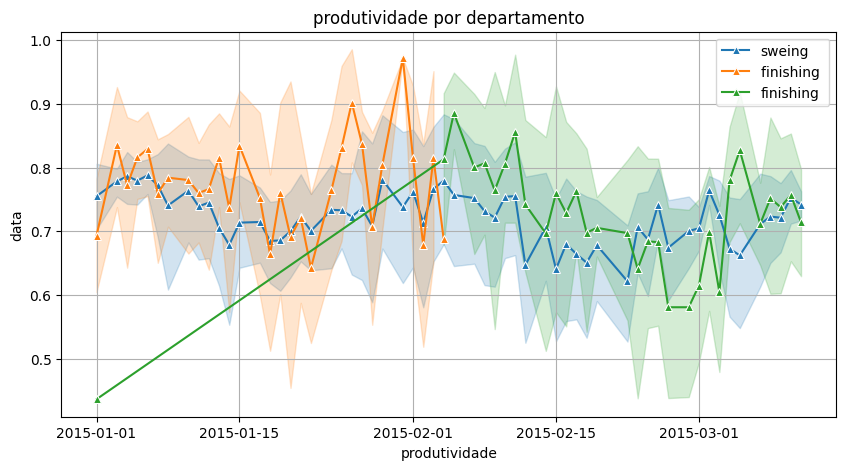

In [137]:
#plotando grafico produtividade por departamento 
plt.figure(figsize=(10,5))
plt.title('produtividade por departamento')
sns.lineplot(data=df, x='date', y='actual_productivity', hue='department', marker='^')
plt.xlabel('produtividade')
plt.ylabel('data')
plt.grid()
plt.legend()
plt.show()

O departamento de costura apresenta um desempenho abaixo dos demais departamentos.

Em qual período do mês a produtividade é maior?



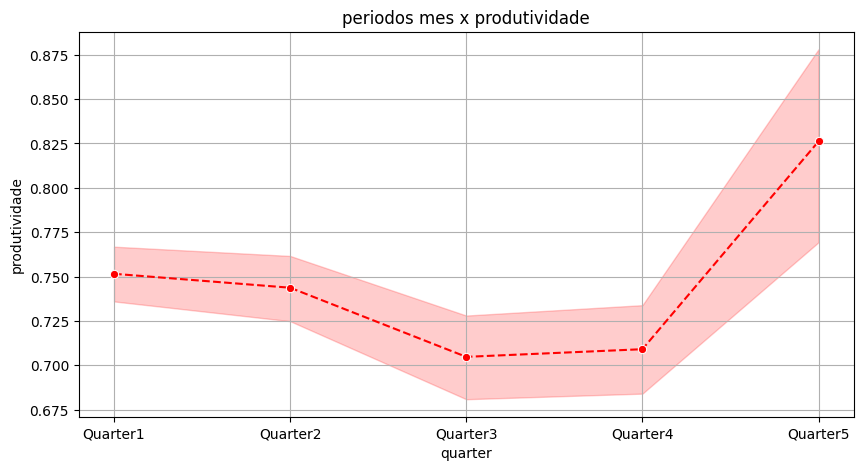

In [138]:
#plotando grafico quarter x produtividade
plt.figure(figsize=(10,5))
plt.title('periodos mes x produtividade')
sns.lineplot(data=df, x='quarter', y='actual_productivity', palette='dark', marker='o', color='red', linestyle='--')
plt.ylabel('produtividade')
plt.grid()
plt.show()

Qual o tempo de ociosidade dos trabalhadores por departamentos?

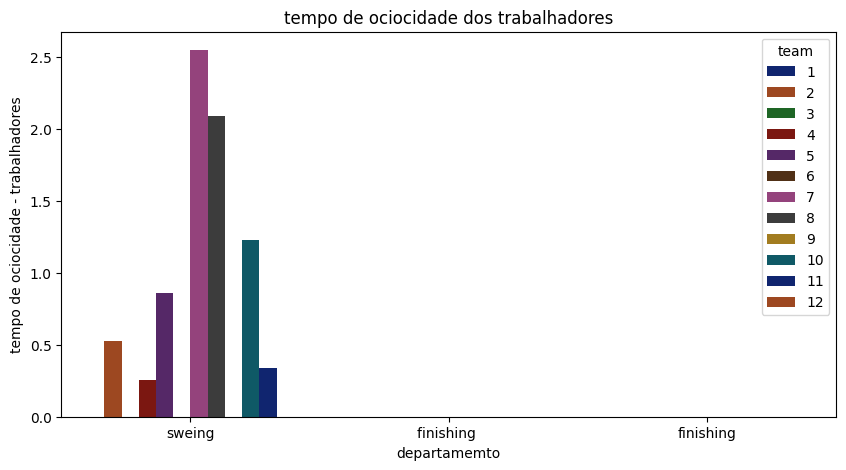

In [139]:
#plotando grafico department x idle_men 
plt.figure(figsize=(10,5))
plt.title('tempo de ociocidade dos trabalhadores')
sns.barplot(data=df, x='department', y='idle_men', ci=None, hue='team', palette='dark')
plt.xlabel('departamemto')
plt.ylabel('tempo de ociocidade - trabalhadores')
plt.show()

O departamento de costura apresentou tempos significativos de trabalhadores ociosos, com a equipe 7 sendo a líder em trabalhadores ociosos, seguida pela equipe 8.

Qual o tempo de ociosidade das maquinas por departamentos?


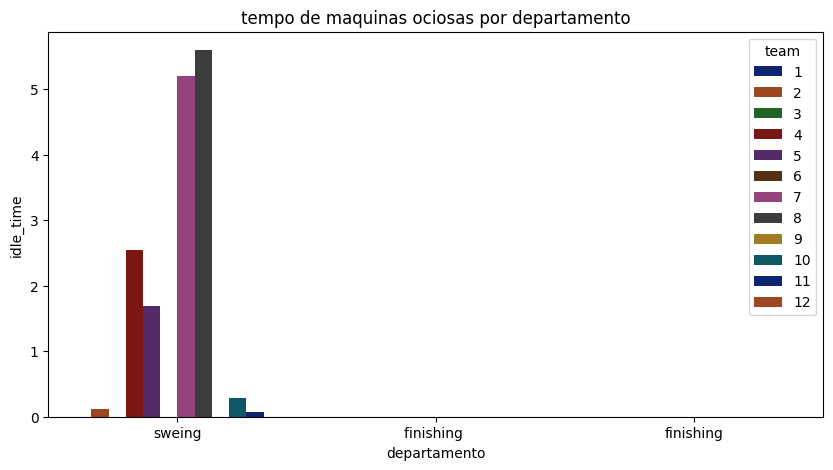

In [140]:
#grafico department x idle_time
plt.figure(figsize=(10,5))
plt.title('tempo de maquinas ociosas por departamento')
sns.barplot(data=df, x='department', y='idle_time', hue='team', ci=None, palette='dark')
plt.xlabel('departamento')
plt.ylabel('idle_time')
plt.show()

O departamento de costura apresentou um grande número de máquinas ociosas por equipe, sendo a equipe 8 a líder em máquinas ociosas, seguida pela equipe 7.

Qual é o departamento que mais muda o seu estilo de produção?

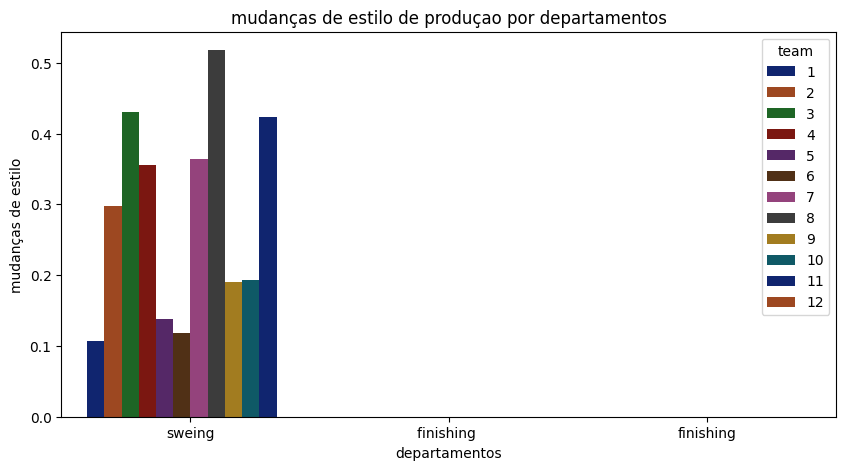

In [141]:
#grafico department x no_of_style_change
plt.figure(figsize=(10,5))
plt.title('mudanças de estilo de produçao por departamentos')
sns.barplot(data=df, x='department', y='no_of_style_change', hue='team', ci=None, palette='dark')
plt.xlabel('departamentos')
plt.ylabel('mudanças de estilo')
plt.show()

Como nas análises anteriores, as equipes 7 e 8 estão entre as que mais mudaram seu estilo de produção. Destaco aqui que a mudança no estilo de produção leva trabalhadores e máquinas a ficarem ociosos durante as trocas, afetando assim a produtividade final.

Um ponto importante a ser destacado é a presença das equipes 3 e 11 no gráfico.

Quero buscar entender se a quantidade de produtos não finalizados(wip) impactam a produtividade

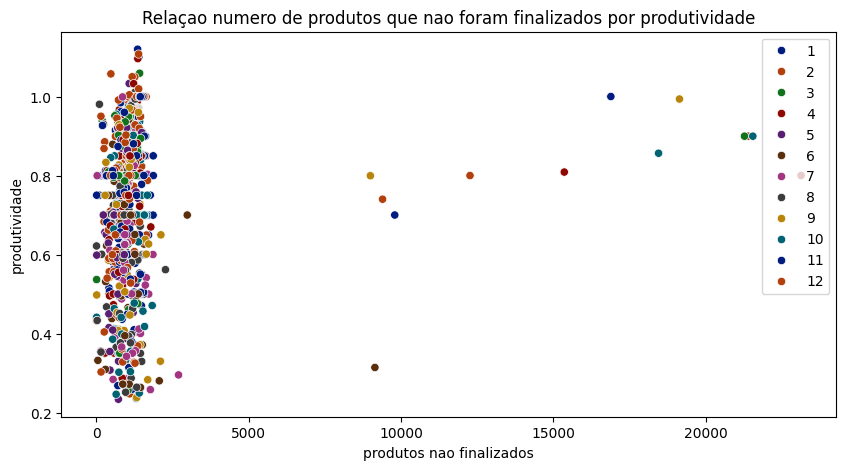

In [142]:
#wip x produtividade 
plt.figure(figsize=(10,5))
plt.title('Relaçao numero de produtos que nao foram finalizados por produtividade')
sns.scatterplot(data=df, x='wip', y='actual_productivity', hue='team', palette='dark')
plt.xlabel('produtos nao finalizados')
plt.ylabel('produtividade')
plt.legend()
plt.show()

Como podemos observar, há um comportamento estranho nessa relação. Há uma grande quantidade de produtos não finalizados; porém, graficamente, eles não parecem interferir diretamente na produtividade.

Qual é a quantidade de produtos não finalizados por departamentos?


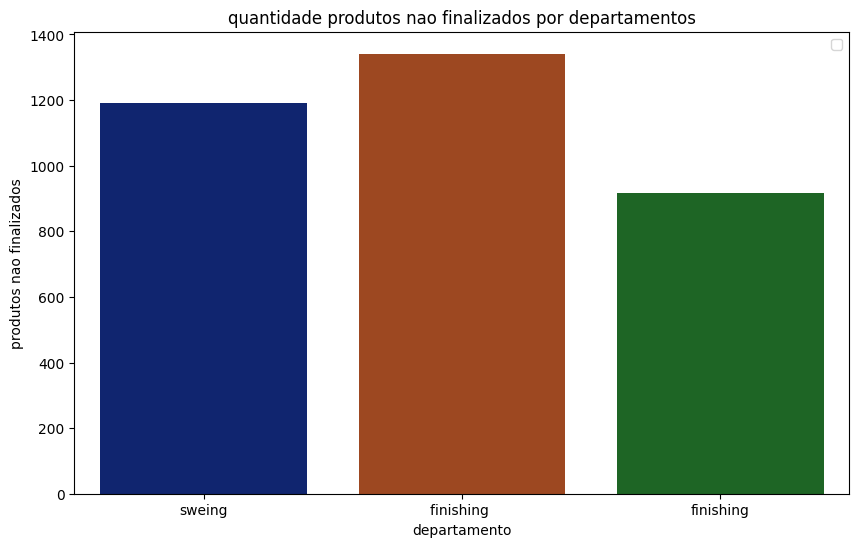

In [143]:
plt.figure(figsize=(10,6))
plt.title('quantidade produtos nao finalizados por departamentos')
sns.barplot(data=df, x='department', y='wip', ci=False, palette='dark')
plt.xlabel('departamento')
plt.ylabel('produtos nao finalizados')
plt.legend()
plt.show()

Enxergando os dois departamentos de finalização como um só, podemos indicar que há uma grande quantidade de peças não finalizadas por esse departamento.
O que está levando a isso, já que nesses setores não há máquinas ou trabalhadores ociosos, como explorado em análises anteriores.

horas extras por departamento 

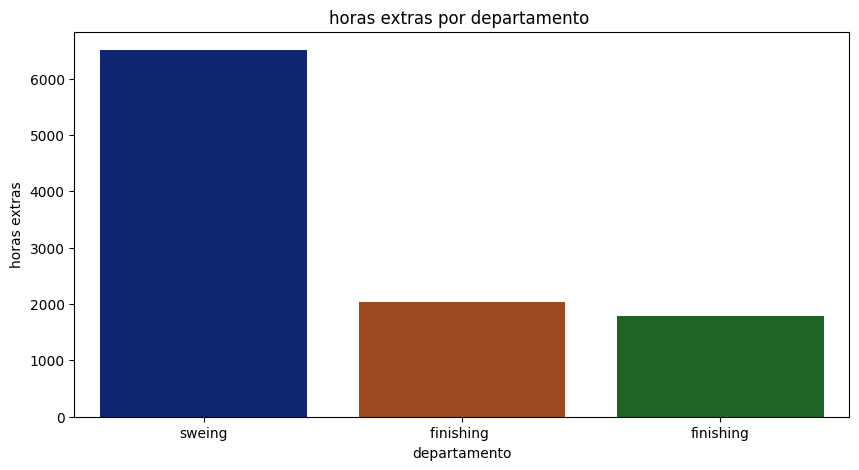

In [144]:
plt.figure(figsize=(10,5))
plt.title('horas extras por departamento ')
sns.barplot(data=df, x='department', y='over_time', ci=False, palette='dark')
plt.xlabel('departamento')
plt.ylabel('horas extras')
plt.show()

Além do departamento de costura ter uma grande quantidade de maquinas ociosas, tambem há uma grande carga horaria em relação as horas extras

Qual período do mês há maior concentração de horas extras?

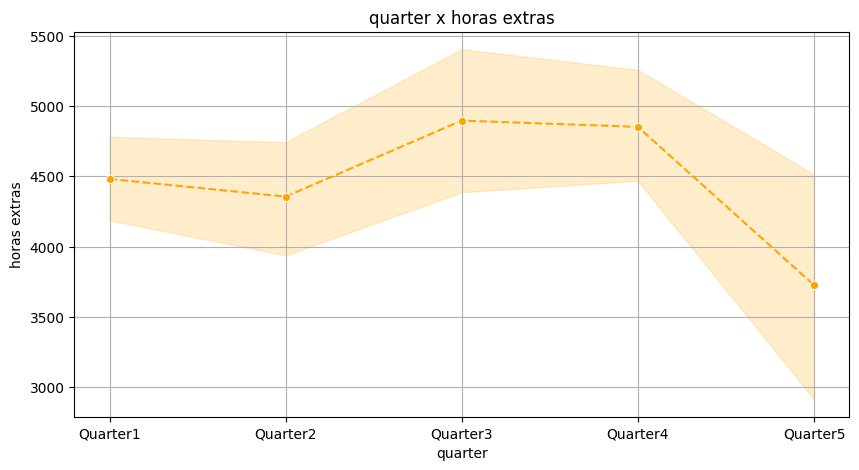

In [ ]:
#grafico quarter x over_time
plt.figure(figsize=(10,5))
plt.title('quarter x horas extras')
sns.lineplot(data=df, x='quarter', y='over_time', color='orange', marker='o', linestyle='--')
plt.ylabel('horas extras')
plt.grid()
plt.show()

Observamos que, após o quarto trimestre, a quantidade de horas extras diminui drasticamente, apresentando uma queda acentuada. Isso ocorre justamente no período do mês em que a produtividade aumenta significativamente.

Para entender o motivo dessa carga de horas extras, vou estudar a relação com os incentivos.

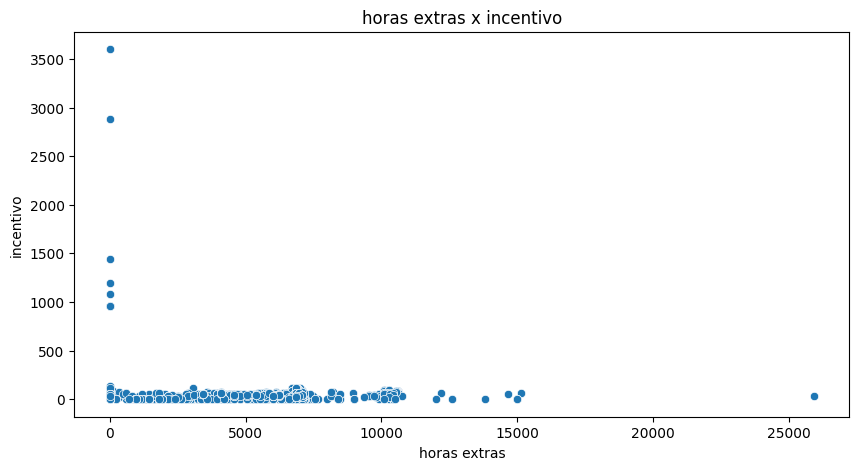

In [145]:
plt.figure(figsize=(10,5))
plt.title('horas extras x incentivo')
sns.scatterplot(data=df, x='over_time', y='incentive')
plt.xlabel('horas extras')
plt.ylabel('incentivo')
plt.show()

há um erro a distribuiçao de incentivos. Deveria ser uma relaçao quase linear entre o dinheiro de incentivo a quantidade de horas extras. Mas parece que esse dinheiro é mal distribuido na empresa. Isso impacta DIRETAMENTE a produtividade do trabalhador

Relação incentivo x produtividade

Text(0, 0.5, 'produtividade')

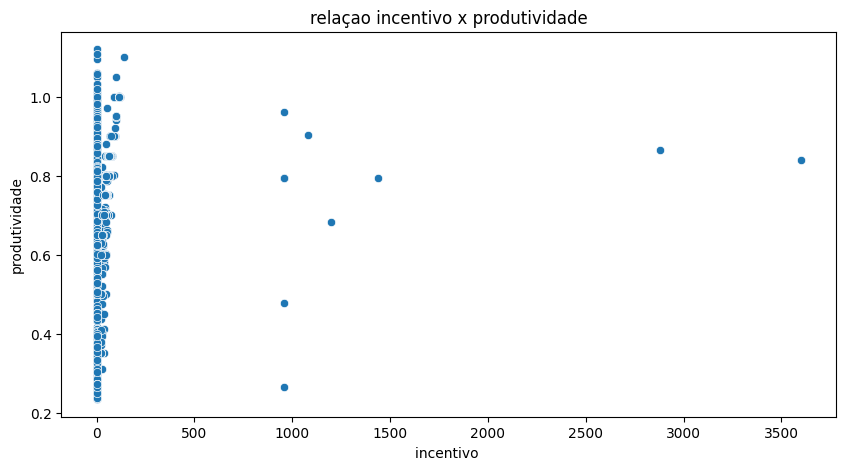

In [146]:
plt.figure(figsize=(10,5))
plt.title('relaçao incentivo x produtividade')
sns.scatterplot(data=df, x='incentive', y='actual_productivity')
plt.xlabel('incentivo ')
plt.ylabel('produtividade')

Periodo do mês onde há maior incetivo 

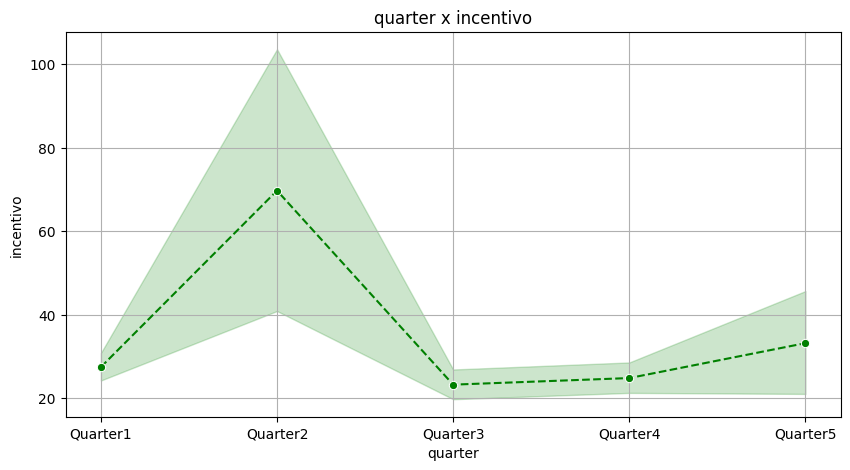

In [209]:
#grafico quarter x incentive
plt.figure(figsize=(10,5))
plt.title('quarter x incentivo')
sns.lineplot(data=df, x='quarter', y='incentive', color='green', linestyle='--', marker='o')
plt.ylabel('incentivo')
plt.grid()
plt.show()

Confirmando a má distribuição de incentivos entre as equipes. 

**Conclusões:**


- Há má distribuição das equipes entre os departamentos.

- Algumas equipes não conseguem atingir a meta de produtividade estipulada.

    -> Essas mesmas equipes se encontram onde há maior incidência de máquinas e trabalhadores ociosos.

    -> Essas equipes também estão entre as que mais mudaram seu estilo de produção.

- A má distribuição das equipes impacta diretamente na capacidade de finalizar os produtos pós-costura. Como consequência, gera-se uma grande quantidade de produtos inacabados. 

- Há também uma grande carga horária concentrada em horas extras.

- Existem períodos no mês em que há maior incidência de horas extras, o que impacta diretamente na capacidade produtiva.

- Dentro da empresa, não há uma distribuição adequada entre incentivo e horas extras. Ou seja, a equipe trabalha muito e não é recompensada por isso.

- Além disso, devido à má distribuição dos incentivos, não há relação entre incentivo e produtividade.

**Soluções**

- Redistribuir as equipes de forma mais eficiente, com base na análise de produtividade e utilização de recursos.

- Implementar gatilhos automáticos: caso o idle_time > 10 ou idle_men > 10, acionar o gestor IMEDIATAMENTE para ações corretivas.

- Reduzir trabalhadores ociosos por meio de treinamentos multitarefas, garantindo que os colaboradores possam atuar em várias funções e não fiquem ociosos.

- nvestir em incentivos direcionados: recompensar apenas as equipes que atingem ou superam as metas de produtividade estipuladas.

- Diminuir horas extras sem justificativa: implementar uma política mais rígida para controle de horas extras, priorizando a eficiência no uso do tempo.

- Penalizar horas extras excessivas: estabelecer um limite máximo para horas extras (por exemplo, no máximo 4 horas extras por colaborador por semana), com penalidades para o descumprimento.

- Análise contínua de produtividade: utilizar ferramentas de monitoramento de produtividade para diminuir incidencia de dados nulos (como na coluna WIP).

- Revisão periódica de processos: realizar auditorias regulares nos processos produtivos para identificar áreas de melhoria e otimizar o desempenho geral das equipes.


**Criação de novas features**

In [147]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

In [148]:
#criaçao de novas features
df['prod_per_worker'] = df['actual_productivity']/df['no_of_workers']
df['diference_prod_targeted_actual'] = df['actual_productivity'] - df['targeted_productivity']
df['time_per_worker'] = df['smv']/ df['no_of_workers']
df['idle_men_percent'] = df['idle_men']/df['no_of_workers']
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,prod_per_worker,diference_prod_targeted_actual,time_per_worker,idle_men_percent
0,2015-01-01,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,0.015944,0.140725,0.443390,0.0
1,2015-01-01,Quarter1,finishing,Thursday,1,0.75,3.94,1038.0,960,0,0.0,0,0,8.0,0.886500,0.110812,0.136500,0.492500,0.0
2,2015-01-01,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0.026248,0.000570,0.374098,0.0
3,2015-01-01,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0.026248,0.000570,0.374098,0.0
4,2015-01-01,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,0.014293,0.000382,0.462500,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,2015-03-11,Quarter2,finishing,Wednesday,10,0.75,2.90,935.0,960,0,0.0,0,0,8.0,0.628333,0.078542,-0.121667,0.362500,0.0
1193,2015-03-11,Quarter2,finishing,Wednesday,8,0.70,3.90,935.0,960,0,0.0,0,0,8.0,0.625625,0.078203,-0.074375,0.487500,0.0
1194,2015-03-11,Quarter2,finishing,Wednesday,7,0.65,3.90,935.0,960,0,0.0,0,0,8.0,0.625625,0.078203,-0.024375,0.487500,0.0
1195,2015-03-11,Quarter2,finishing,Wednesday,9,0.75,2.90,935.0,1800,0,0.0,0,0,15.0,0.505889,0.033726,-0.244111,0.193333,0.0


In [149]:
new_features = ['prod_per_worker','diference_prod_targeted_actual',  'time_per_worker', 'idle_men_percent']

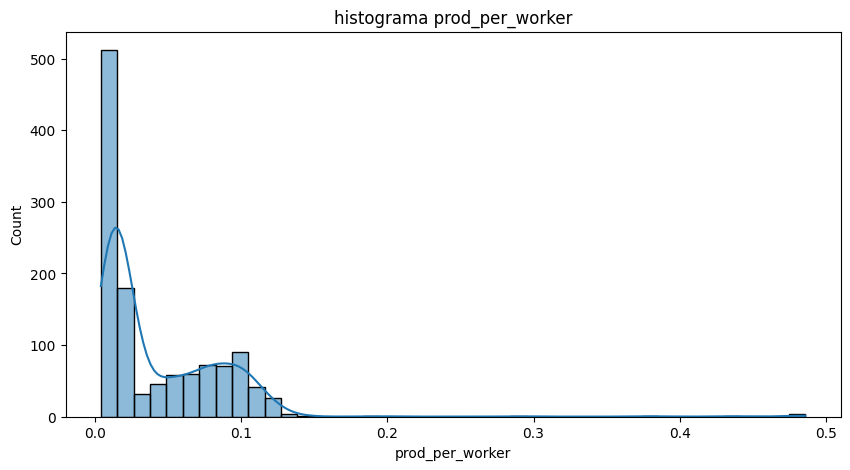

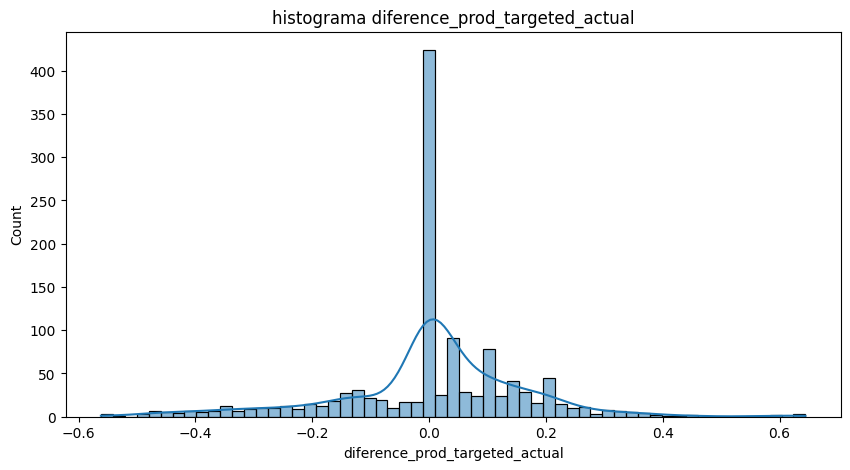

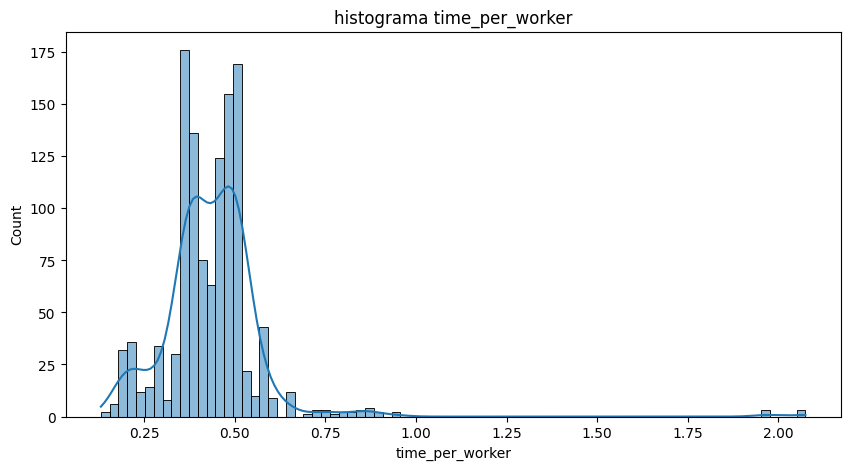

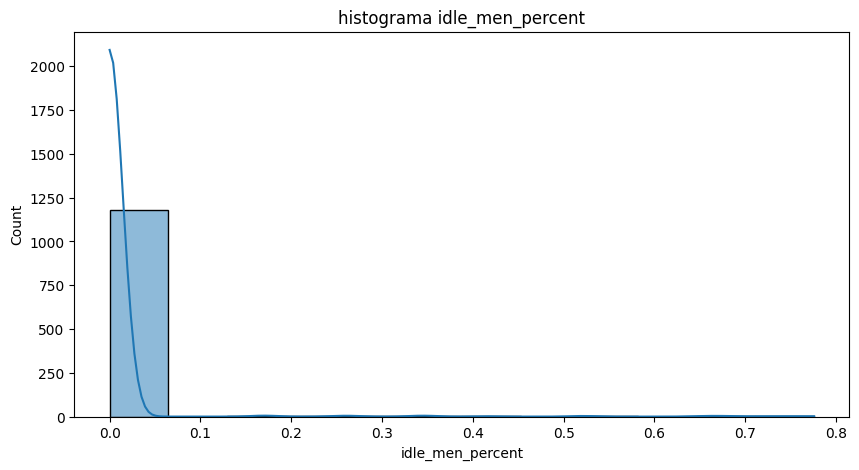

In [150]:
#distribuiçao de novas features
for hist in new_features:
    plt.figure(figsize=(10,5))
    plt.title(f'histograma {hist}')
    sns.histplot(df[hist], kde=True)
plt.show()

In [151]:
new_num_col = df.select_dtypes(exclude=['object', 'datetime64[ns]'])
new_num_col

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,prod_per_worker,diference_prod_targeted_actual,time_per_worker,idle_men_percent
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,0.015944,0.140725,0.443390,0.0
1,1,0.75,3.94,1038.0,960,0,0.0,0,0,8.0,0.886500,0.110812,0.136500,0.492500,0.0
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0.026248,0.000570,0.374098,0.0
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0.026248,0.000570,0.374098,0.0
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,0.014293,0.000382,0.462500,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,10,0.75,2.90,935.0,960,0,0.0,0,0,8.0,0.628333,0.078542,-0.121667,0.362500,0.0
1193,8,0.70,3.90,935.0,960,0,0.0,0,0,8.0,0.625625,0.078203,-0.074375,0.487500,0.0
1194,7,0.65,3.90,935.0,960,0,0.0,0,0,8.0,0.625625,0.078203,-0.024375,0.487500,0.0
1195,9,0.75,2.90,935.0,1800,0,0.0,0,0,15.0,0.505889,0.033726,-0.244111,0.193333,0.0


**Matriz correlação**

<function matplotlib.pyplot.show(close=None, block=None)>

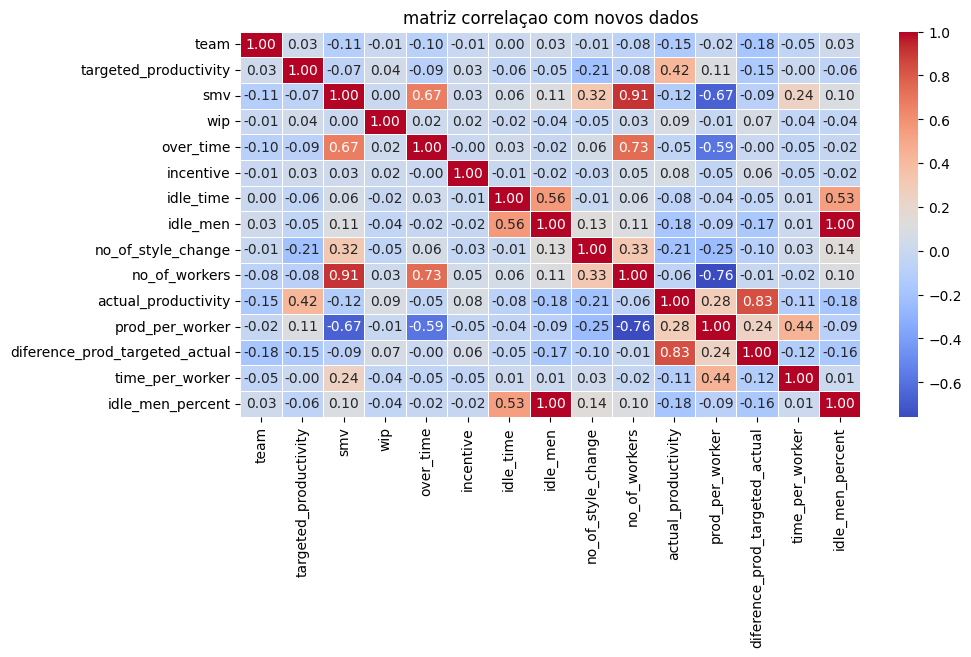

In [152]:
#plotando nova matriz de correlaçao
plt.figure(figsize=(10,5))
plt.title('matriz correlaçao com novos dados')
sns.heatmap(new_num_col.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.show

**Modelagem**

In [153]:
#colocando data como index 
df = df.set_index(df['date'])
df = df.drop('date', axis=1)

In [154]:
df.columns

Index(['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv',
       'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity',
       'prod_per_worker', 'diference_prod_targeted_actual', 'time_per_worker',
       'idle_men_percent'],
      dtype='object')

In [155]:
#escolhendo x e y 
x = df.drop('actual_productivity', axis=1)
y = df['actual_productivity']

In [156]:
x.shape, y.shape

((1197, 17), (1197,))

In [157]:
#split
split_size = 0.9
train_size = int(len(df) * split_size)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
x_valid, y_valid = x[train_size:], y[train_size:]

In [158]:
x_train.shape, x_test.shape

((1077, 17), (120, 17))

In [159]:
y_train.shape, y_test.shape

((1077,), (120,))

In [160]:
x_valid.shape, y_valid.shape

((120, 17), (120,))

In [161]:
new_num_col.columns

Index(['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
       'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
       'actual_productivity', 'prod_per_worker',
       'diference_prod_targeted_actual', 'time_per_worker',
       'idle_men_percent'],
      dtype='object')

In [162]:
cat_col

Index(['quarter', 'department', 'day'], dtype='object')

In [163]:
#separaçao de atributos 
num_atribs = ['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
       'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
       'prod_per_worker',
       'diference_prod_targeted_actual', 'time_per_worker',
       'idle_men_percent']
        
cat_atribs = ['quarter', 'department', 'day']

In [164]:
#pipeline numerica
num_pipeline = Pipeline([
    ('robust_scaler', RobustScaler()),
])

In [165]:
#transformaçao de colunas 
column_tranf = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_atribs),  
    ('1hot_enc', OneHotEncoder(), cat_atribs)   
])

In [166]:
#definiçao da pipe
pipe = Pipeline([('transform', column_tranf),
                ('model', Lasso())
    
])

In [167]:
#teste da pipe
pipe.set_params(model=Ridge()).fit(x_train, y_train)
pipe_pred = pipe.predict(x_test)


In [168]:
#funçao para calcular metricas 
def metrics(model_name, y_test, y_pred):
    result_list = []
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred) 
    mean_percent = mean_absolute_percentage_error(y_test, y_pred)
    
    results = {'model_name':model_name,
        'mse':mse,
        'mae':mae,
        'r2':r2,
        'mean_percent':mean_percent,
        
    }
    result_list.append({'model_name':results['model_name'],
                    'mse':results['mse'],
                    'mae':results['mae'],
                    'r2':results['r2'],
                    'mean_percent':results['mean_percent']})
    return pd.DataFrame(result_list)

In [169]:
 metrics(model_name=Ridge(), y_test=y_test, y_pred=pipe_pred)

,model_name,mse,mae,r2,mean_percent
0,Ridge(),0.000016,0.001102,0.999314,0.001621


**Treinamento e avaliaçao dos modelos**

In [170]:
models =  {'Reg_linear':LinearRegression(),
        'D_tree':DecisionTreeRegressor(),
        'Ada_reg': AdaBoostRegressor(),
        'Neural_net':MLPRegressor(),
        'Reg_lasso':Lasso(),
        'Ridge':Ridge(),
        'SVR': SVR()
    
}

In [171]:
#loop treino/teste
for i, (model_name, model) in enumerate(models.items()):
    pipe.set_params(model=model).fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    metrics_out = metrics(model_name=model_name, y_pred=y_pred, y_test=y_test)
    
    print('--------------------'*10)
    print(metrics_out)
    

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   model_name           mse           mae   r2  mean_percent
0  Reg_linear  3.614842e-31  3.261280e-16  1.0  5.249231e-16
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  model_name       mse      mae        r2  mean_percent
0     D_tree  0.001184  0.01475  0.948017       0.02519
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  model_name       mse       mae        r2  mean_percent
0    Ada_reg  0.002001  0.035537  0.912144      0.054965
-------------------------------------------------

**Cross val score**

In [172]:
for i, (val_name, val_score) in enumerate(models.items()):
    estimator = pipe.set_params(model=val_score).fit(x_train, y_train)
    cross_val = cross_val_score(estimator, x_train, y_train, cv=10, scoring='r2')
    val_results = {
                'score':cross_val, 
        'score_max':cross_val.max(),
                'score_min':cross_val.min(),
                'score_media':cross_val.mean()
    }
    print(val_name)
    print(val_results)
    print('--------------------'*10)


Reg_linear
{'score': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), 'score_max': 1.0, 'score_min': 1.0, 'score_media': 1.0}
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
D_tree
{'score': array([0.98966182, 0.97861882, 0.92391351, 0.92159877, 0.95455146,
       0.98848611, 0.96480227, 0.98784438, 0.98767276, 0.97524237]), 'score_max': 0.9896618241530721, 'score_min': 0.921598766303693, 'score_media': 0.9672392285638679}
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Ada_reg
{'score': array([0.75192412, 0.84251178, 0.89397381, 0.94573231, 0.91862933,
       0.9052923 , 0.91376225, 0.9390269 , 0.92897642, 0.87632644]), 'score_max': 0.9457323088731788, 'score_min': 0.7519241166337538,

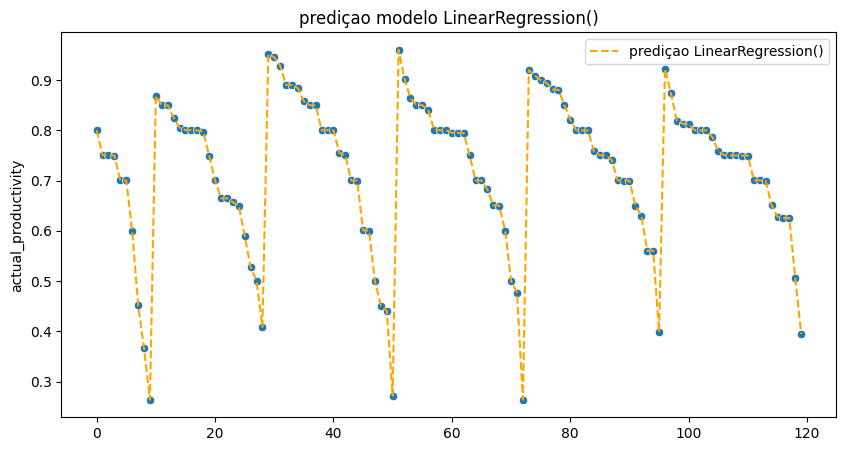

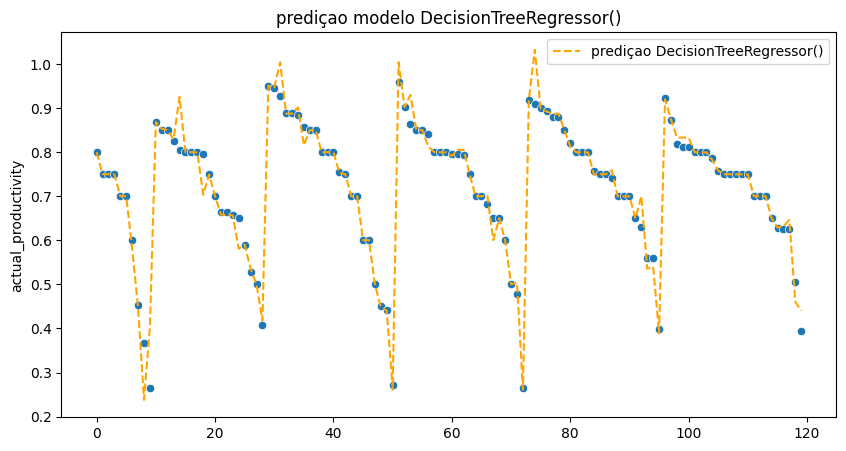

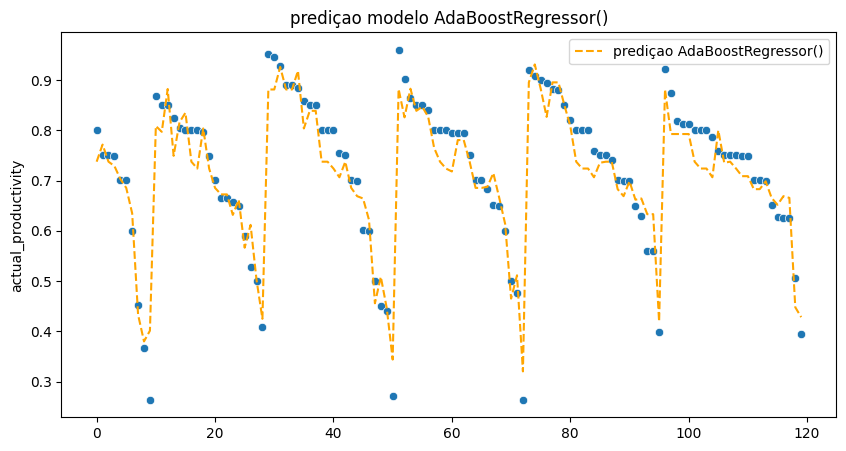

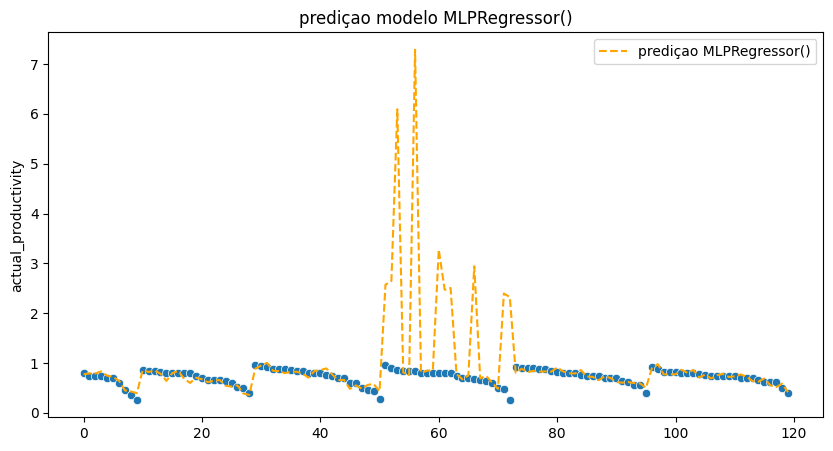

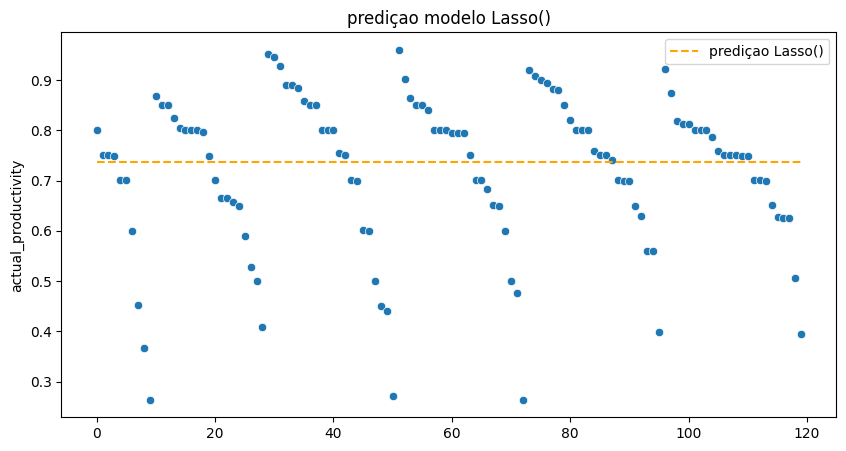

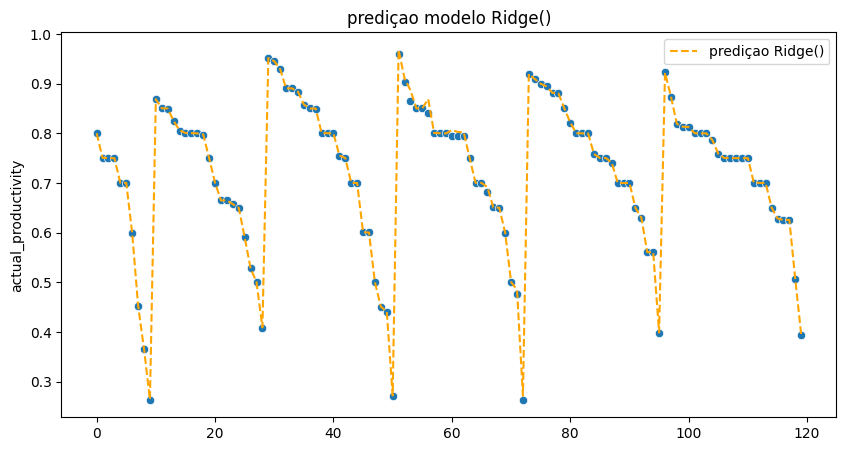

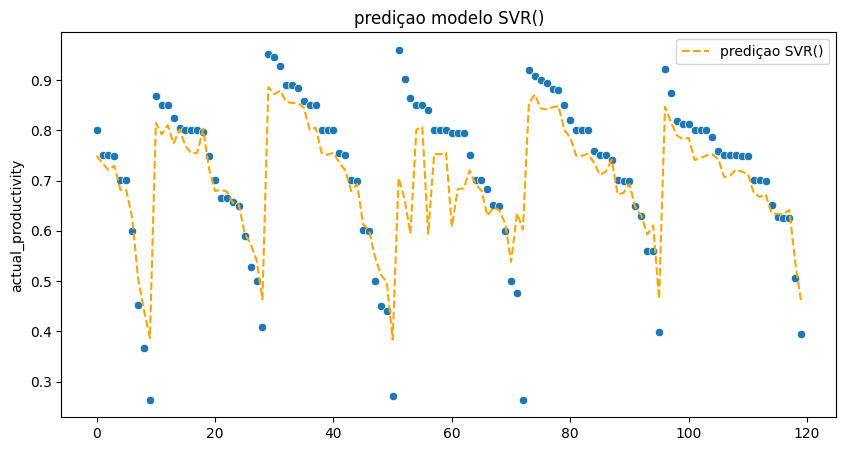

In [173]:
#plotando y e linhas de prediçao 
for i, testes in models.items():
    pipe.set_params(model=testes).fit(x_train, y_train)
    _pred = pipe.predict(x_test)
    plt.figure(figsize=(10,5))
    plt.title(f'prediçao modelo {testes}')
    sns.scatterplot(x=range(len(y_test)), y=y_test)
    sns.lineplot(_pred, color='orange', label=f'prediçao {testes}', linestyle='--')  

**Relatório dos Modelos**

**Regressão Linear**

Métricas:

MSE: 3.614842e-31

MAE: 3.261280e-16

R²: 1.0

Mean Percent: 5.249231e-16

-> Apresenta scores extremamente altos pela baixa complexidade do modelo em relação aos dados, podendo indicar overfitting.

**Árvores de Decisão**

Métricas:

MSE: 0.001089

MAE: 0.014322

R²: 0.952174

Mean Percent: 0.024498

-> Boas métricas, com erro baixo e bom desempenho em relação à variabilidade dos dados.

Pode ser uma boa escolha para aplicação futura.

**AdaBoosting**

Métricas:

MSE: 0.001937

MAE: 0.035939

R²: 0.914977

Mean Percent: 0.056122

-> Assim como a árvore de decisão, o AdaBoost apresenta bom desempenho e trabalha bem com a variabilidade dos dados.

Pode ser considerado para futuro deploy, levando em conta o custo operacional.

**Rede Neural**

Métricas:

MSE: 0.168849

MAE: 0.140431

R²: -6.413276

Mean Percent: 0.207295

-> Desempenho ruim, com erros altos e baixo score em R².

Dos modelos treinados, é um dos piores.

O desempenho pode melhorar significativamente se ajustarmos os hiperparâmetros.

**Regressão Lasso**

Métricas:

MSE: 0.022963

MAE: 0.114869

R²: -0.008171

Mean Percent: 0.207104

-> Desempenho ruim, com R² próximo de 0.

Não deve ser levado em consideração neste experimento.

**Regressão Ridge**

Métricas:

MSE: 0.000016

MAE: 0.001102

R²: 0.999314

Mean Percent: 0.001621

-> Vencedor do experimento.

Beira a perfeição, explicando muito bem a variabilidade dos dados (R² alto) e apresentando erros muito baixos.

Modelo recomendado para produção.

**SVR (Suporte a Vetores)**

Métricas:

MSE: 0.005414

MAE: 0.049011

R²: 0.762313

Mean Percent: 0.079265

-> Desempenho intermediário.

R² abaixo do esperado, o que limita sua aplicabilidade.

**Multicolinaridade**

Nossos dados indicam a presença de multicolinearidade, ou seja, duas ou mais variáveis independentes apresentam uma correlação muito alta. Isso pode prejudicar o desempenho do nosso modelo de regressão, reduzindo sua capacidade de generalização e tornando as estimativas dos coeficientes menos confiáveis. Para melhorar a robustez do modelo, é importante identificar e tratar a multicolinearidade adequadamente.

**PCA**

O PCA transforma os dados originais em um novo conjunto de variáveis não correlacionadas, chamadas componentes principais. Isso ajuda a resolver a multicolinearidade, pois as novas variáveis são ortogonais entre si. Sendo ortogonais, essas variáveis não possuem correlação entre si.

In [174]:
#pipe pca
pipe_pca = Pipeline([('transform', column_tranf),
                ('pca', PCA()),
                ('model', Lasso())
            
    
])

In [175]:
pipe_pca.set_params(model=Ridge()).fit(x_train, y_train)
pca_pred = pipe_pca.predict(x_test)
metrics(model_name=Lasso(), y_pred=pca_pred, y_test=y_test)

,model_name,mse,mae,r2,mean_percent
0,Lasso(),0.000016,0.001102,0.999314,0.001621


In [176]:
#loop treinp/teste utilizando pca 
print('treino/avaliaçao pós PCA')
for i, (pca_name, model_pca) in enumerate(models.items()):
    pipe.set_params(model=model_pca).fit(x_train, y_train)
    pca_pred = pipe.predict(x_test)
    pca_out = metrics(model_name=pca_name, y_pred=pca_pred, y_test=y_test)
    print('-------------------------------'*10)
    print(pca_out)

treino/avaliaçao pós PCA
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   model_name           mse           mae   r2  mean_percent
0  Reg_linear  3.614842e-31  3.261280e-16  1.0  5.249231e-16
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  model_name       mse      mae        r2  mean_percent
0     D_tree  0.001075  0.01321  0.952792      0.021938
-----------------------------------------------------------------------------------------------------------------------

No geral, usamos o PCA para tratar a multicolinearidade de nossos modelos. No entanto, observamos uma pequena melhora nos modelos baseados em árvore de decisão. Os outros modelos nao apresentaram mudanças significativas. 

A regressão Ridge manteve seu desempenho ótimo.

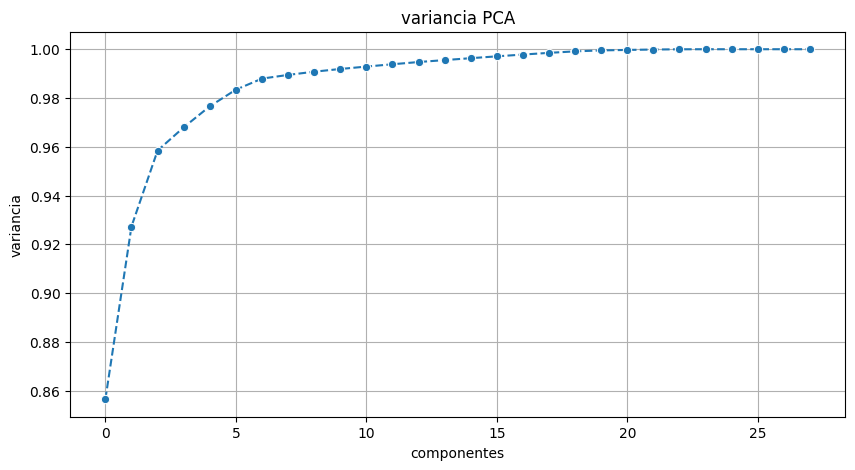

In [177]:
#vizualizando variancia 
pca = pipe_pca.named_steps['pca']
plt.figure(figsize=(10,5))
plt.title('variancia PCA')
sns.lineplot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('componentes')
plt.ylabel('variancia')
plt.grid()
plt.show()



**Redes neurais - Pytorch**

Nessa parte do projeto eu escolhi trabalhar um pouco com o Pytorch, afim de explorar redes profundas.
Por tratar de dados temporais, vamos utilizar modelos baseados em recorrencia: LSTM e GRU

Redes recorrentes utilizam a lógica de loop, ou seja, a informação retorna ao processamento, permitindo que os dados persistam.

**Long Short Term Memory (LSTM)**

As LSTM são redes recorrentes que "lembram" informações de forma mais eficiente, resolvendo problemas como o desaparecimento e explosão do gradiente. Elas possuem células com três portas principais: a porta de entrada, que controla as novas informações a serem armazenadas; a porta de esquecimento, que decide o que deve ser descartado; e a porta de saída, que define as informações usadas na saída. Essa estrutura permite que as LSTM capturem dependências de longo prazo em dados sequenciais, sendo eficazes em tarefas como tradução automática e reconhecimento de fala.



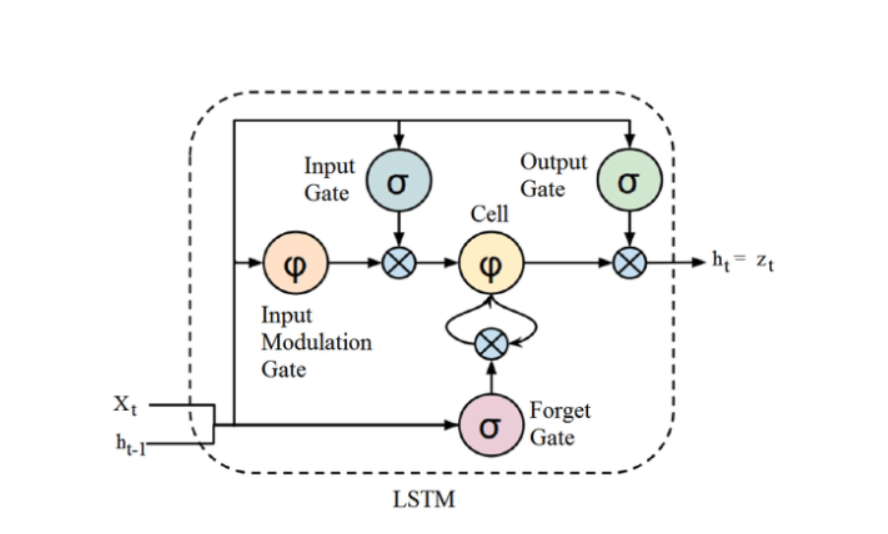

In [178]:
#setando seed
torch.manual_seed(42)


In [179]:
x_train.shape

(1077, 17)

In [180]:
#criaçao da classe da LSTM
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.LSTM1 = nn.LSTM(input_size=28, hidden_size=300)
        self.LSTM2 = nn.LSTM(300, 150)
        self.LSTM3 = nn.LSTM(150, 50)
        self.LSTM4 = nn.LSTM(50, 50, dropout=0.3, num_layers=2)
        self.dropout = nn.Dropout(p=0.3)
        self.linear = nn.Linear(50, 1)  
        
    def forward(self, x):
        x, (h1, c1) = self.LSTM1(x)
        x, (h2, c2) = self.LSTM2(x)
        x, (h3, c3) = self.LSTM3(x)
        x, (h4, c4) = self.LSTM4(x)
        x = self.dropout(x)
        x = x[:, -1, :]  
        x = self.linear(x)
        
        return x

        


In [181]:
#escolhendo criterio para o erro e optimizador 
model_lstm = LSTM()
criterion = nn.MSELoss()
optmizer = optim.SGD(model_lstm.parameters())

In [182]:
#tranformaçao dos dados 
pipe_transf = Pipeline(steps=[
    ('transf', column_tranf)
])
x_train_torch = pipe_transf.fit_transform(x_train)

In [183]:
#transformaçao dados em np.array
x_array = np.array(x_train_torch)
y_array = np.array(y_train)
type(y_array), type(x_array)

(numpy.ndarray, numpy.ndarray)

In [184]:
#transformaçao dados em tensores 
x_train_tensor = torch.Tensor(x_array)
y_train_tensor = torch.Tensor(y_array)
x_train_tensor = x_train_tensor.unsqueeze(1) 
y_train_tensor = y_train_tensor.long()


In [185]:
print(x_train_tensor.shape)  


torch.Size([1077, 1, 28])


estatisticas do treinamento - LSTM
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
epoca 0 erro: 0.03472690284252167
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
epoca 1 erro: 0.034724440425634384
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

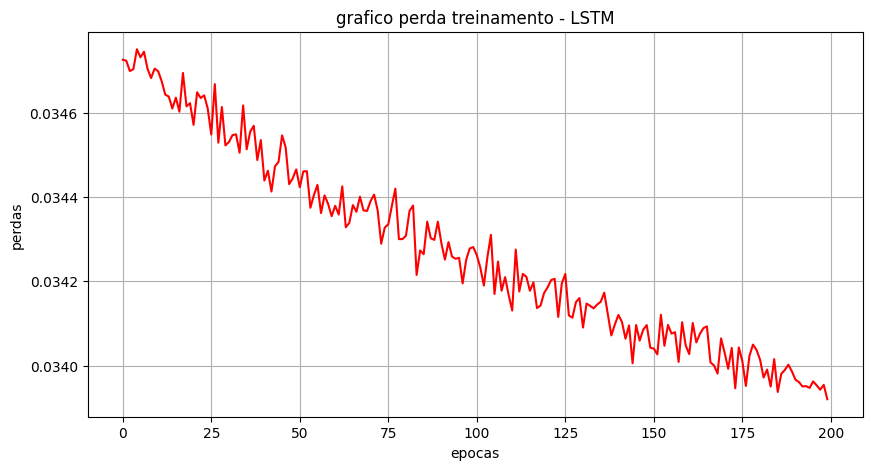

In [186]:
#loop treinamento LSTM 
print('estatisticas do treinamento - LSTM')
losses = []
for epoch in range(200):
    model_lstm.train()
    lstm_pred = model_lstm(x_train_tensor)
    lstm_pred = lstm_pred.float()
    y_train_tensor = y_train_tensor.float()
    loss = criterion(lstm_pred, y_train_tensor)
    losses.append(loss.item()) 
    
    optmizer.zero_grad()
    loss.backward()
    optmizer.step()
    
    print('----------------------------------'*10)
    print(f'epoca {epoch} erro: {loss}')
plt.figure(figsize=(10,5))
plt.title('grafico perda treinamento - LSTM')
plt.plot(losses, color='red')
plt.xlabel('epocas')
plt.ylabel('perdas')
plt.grid()
plt.show()

**Gated Recurrent Unit (GRU)**

As GRUs são um tipo de rede neural recorrente, similar às LSTM, mas com uma estrutura mais simples. Elas também são projetadas para resolver o problema de desaparecimento e explosão do gradiente, mantendo a capacidade de "lembrar" informações em sequências temporais. As GRUs possuem duas portas principais: a porta de atualização, que controla como as informações passadas e novas devem ser combinadas, e a porta de reset, que decide quais informações anteriores devem ser esquecidas

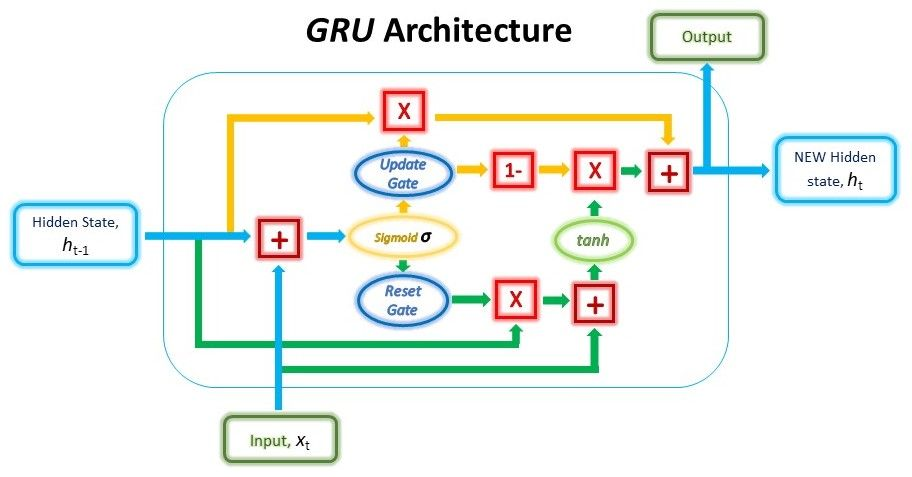

In [187]:
#criaçao da classe GRU 
class GRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru1 = nn.GRU(input_size=28,hidden_size=300, batch_first=True) 
        self.gru2 = nn.GRU(300,150, batch_first=True)
        self.gru3 = nn.GRU(150, 50, batch_first=True)
        self.gru4 = nn.GRU(50, 50)
        self.linear = nn.Linear(50, 1)
        self.dropout = nn.Dropout(0.3)
        self.batch_norm = nn.BatchNorm1d(50)
        
    def forward(self, x):
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x, _ = self.gru3(x)
        x, _ = self.gru4(x)
        x = self.batch_norm(x[:, -1, :])    
        x = self.dropout(x)    
        x = self.linear(x)  
       

        return x

In [188]:
model_gru  = GRU()
criterion_gru = nn.MSELoss()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = StepLR(optimizer_gru, step_size=50, gamma=0.1) 

estatisticas treinamento - GRU
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
epoca 0 erro: 0.8877992630004883
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
epoca 1 erro: 0.31527823209762573
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

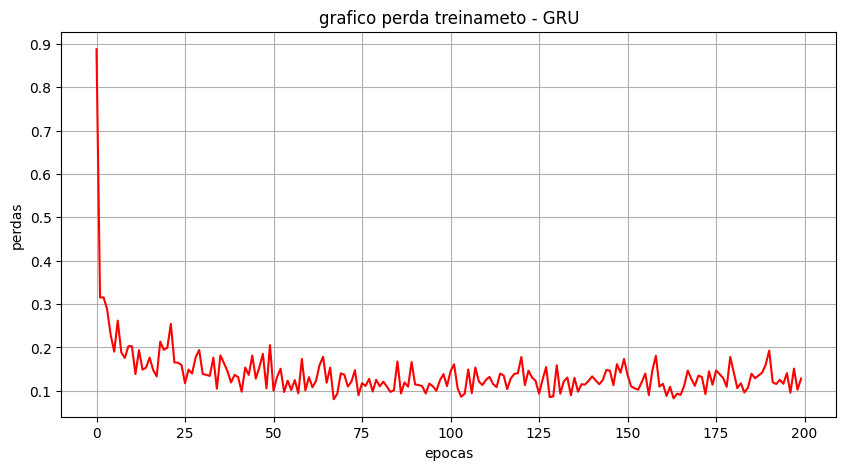

In [189]:
#loop treinamento GRU
print('estatisticas treinamento - GRU')
gru_losses = []
for epoch_gru in range(200):
    model_gru.train()
    gru_pred = model_gru(x_train_tensor).float()
    y_train_tensor = y_train_tensor.float()
    gru_loss = criterion_gru(gru_pred, y_train_tensor)
    gru_losses.append(gru_loss.item())
    
    optimizer_gru.zero_grad()
    gru_loss.backward(retain_graph=True)
    optimizer_gru.step()
    scheduler.step()
    
    print('----------------------------------'*10)
    print(f'epoca {epoch_gru} erro: {gru_loss}')
    

plt.figure(figsize=(10,5))
plt.title('grafico perda treinameto - GRU')
plt.plot(gru_losses, color='red')
plt.xlabel('epocas')
plt.ylabel('perdas')
plt.grid()
plt.show()

Os modelos foram configurados com base nas necessidades de cada treinamento, por isso podemos observar diferenças em alguns parâmetros do critério e do otimizador. No entanto, busquei manter as mesmas características em relação à quantidade de camadas ocultas e outros aspectos da arquitetura.

**Avaliaçao redes neurais**

LSTM 

In [190]:
#colocando modelo em modo de avaliaçao 
model_lstm.eval()

LSTM(
  (LSTM1): LSTM(28, 300)
  (LSTM2): LSTM(300, 150)
  (LSTM3): LSTM(150, 50)
  (LSTM4): LSTM(50, 50, num_layers=2, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [191]:
#transformando dados de teste 
x_test_array = pipe_transf.fit_transform(x_test)
x_test_tensor = torch.Tensor(x_test_array)
y_test_tensor = torch.Tensor(y_test)
y_test_tensor = y_test_tensor.long()
x_test_tensor = x_test_tensor.unsqueeze(1)

In [192]:
x_test_tensor.shape
#o x_test tem 24 entradas, precisamos de 28 

torch.Size([120, 1, 24])

In [193]:
# add criando colunas com 0 
padding = torch.zeros(120, 1, 4)  
x_test_tensor_padded = torch.cat((x_test_tensor, padding), dim=-1) 
x_test_tensor_padded.shape

torch.Size([120, 1, 28])

In [194]:
x_test_tensor_padded.shape

torch.Size([120, 1, 28])

In [195]:
#criaçao de dataloader 
test_dataset = torch.utils.data.TensorDataset(x_test_tensor_padded, y_test_tensor)
test_loader = DataLoader(test_dataset)

In [196]:
#avaliaçao LSTM
total_loss_lstm = 0 
num_batches_lstm = 0
mse = nn.MSELoss()
with torch.no_grad():
    for x, y in test_loader:
        out_lstm = model_lstm(x).squeeze()
        loss_lstm = mse(out_lstm, y)
        total_loss_lstm += loss_lstm.item() 
        num_batches_lstm += 1

mean_mse_lstm = total_loss_lstm / num_batches_lstm
print(f'media MSE: {mean_mse_lstm}')

media MSE: 0.0007733288900150607


GRU

In [197]:
#colocando GRU em modo de avaliaçao 
model_gru.eval()

GRU(
  (gru1): GRU(28, 300, batch_first=True)
  (gru2): GRU(300, 150, batch_first=True)
  (gru3): GRU(150, 50, batch_first=True)
  (gru4): GRU(50, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (batch_norm): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [198]:
#avaliaçao GRU
total_loss_gru = 0
num_batches_gru = 0 
with torch.no_grad():
    for x, y in test_loader:
        out_gru = model_gru(x)
        loss_gru = mse(out_gru, y)
        num_batches_gru += loss_gru.item()
        num_batches_gru+= 1
mean_mse_gru = total_loss_gru / num_batches_gru
print(f'media MSE {mean_mse_gru}')


media MSE 0.0
